In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import math

In [109]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx  # Index of feature to split on
        self.threshold = threshold      # Threshold value for the split
        self.left = left                # Left subtree
        self.right = right              # Right subtree
        self.value = value              # Predicted value (for leaf nodes)


In [111]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None
    
    def fit(self, X, y):
        self.n_features = X.shape[1]
        
        # Handle max_features parameter
        if self.max_features is None:
            self.max_features_val = self.n_features
        elif isinstance(self.max_features, int):
            self.max_features_val = min(self.max_features, self.n_features)
        elif isinstance(self.max_features, float):
            self.max_features_val = int(self.max_features * self.n_features)
        elif self.max_features == "sqrt":
            self.max_features_val = int(math.sqrt(self.n_features))
        elif self.max_features == "log2":
            self.max_features_val = int(math.log2(self.n_features))
        else:
            self.max_features_val = self.n_features
            
        self.root = self._grow_tree(X, y)
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Stopping criteria
        if (self.max_depth is not None and depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            n_classes == 1):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Randomly select features to consider
        feature_idxs = np.random.choice(n_features, min(self.max_features_val, n_features), replace=False)
        
        # Find best split
        best_feature, best_threshold = self._best_split(X, y, feature_idxs)
        
        # Create child nodes
        if best_feature is None:  # No good split found
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Split the data
        left_idxs = X[:, best_feature] <= best_threshold
        right_idxs = ~left_idxs
        
        # Recursively grow the tree
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        
        return Node(feature_idx=best_feature, threshold=best_threshold, left=left, right=right)
    
    def _best_split(self, X, y, feature_idxs):
        best_gain = -float("inf")
        best_feature, best_threshold = None, None
        
        for feature_idx in feature_idxs:
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                # Split the data
                left_idxs = X[:, feature_idx] <= threshold
                right_idxs = ~left_idxs
                
                if np.sum(left_idxs) == 0 or np.sum(right_idxs) == 0:
                    continue
                
                # Calculate information gain
                gain = self._information_gain(y, y[left_idxs], y[right_idxs])
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
                    
        return best_feature, best_threshold
    
    def _information_gain(self, parent, left_child, right_child):
        # Gini impurity
        weight_left = len(left_child) / len(parent)
        weight_right = len(right_child) / len(parent)
        
        gain = self._gini(parent) - (weight_left * self._gini(left_child) + 
                                      weight_right * self._gini(right_child))
        
        return gain
    
    def _gini(self, y):
        # Calculate Gini impurity
        m = len(y)
        if m == 0:
            return 0
        
        counts = np.bincount(y)
        probabilities = counts / m
        gini = 1 - np.sum(probabilities ** 2)
        
        return gini
    
    def _most_common_label(self, y):
        # Find the most common class
        counts = np.bincount(y)
        return np.argmax(counts)
    
    def predict(self, X):
        # Predict class for X
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        # Traverse the tree to predict class
        if node.value is not None:
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

    def plot_tree(self, feature_names=None, class_names=None, max_depth=3):
        if feature_names is None:
            feature_names = [f"feature_{i}" for i in range(self.n_features)]
        if class_names is None:
            # Get unique classes from tree traversal
            all_classes = set()
            self._collect_classes(self.root, all_classes)
            class_names = [f"class_{i}" for i in sorted(list(all_classes))]
            
        plt.figure(figsize=(20, 10))
        self._plot_node(self.root, 0.5, 0.9, 0.4, 0, max_depth, feature_names, class_names)
        plt.axis('off')
        plt.tight_layout()
        
    def _collect_classes(self, node, classes_set):
        if node.value is not None:
            classes_set.add(node.value)
        else:
            if node.left:
                self._collect_classes(node.left, classes_set)
            if node.right:
                self._collect_classes(node.right, classes_set)
    
    def _plot_node(self, node, x, y, dx, depth, max_depth, feature_names, class_names):
        if depth >= max_depth:
            return
        
        if node.value is not None:  # Leaf node
            plt.text(x, y, f"Class: {class_names[node.value]}", 
                    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black"),
                    ha='center', va='center')
        else:
            # Decision node
            plt.text(x, y, f"{feature_names[node.feature_idx]} <= {node.threshold:.2f}",
                    bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", ec="black"),
                    ha='center', va='center')
            
            # Connect to left child
            x_left = x - dx
            y_left = y - 0.1
            plt.plot([x, x_left], [y-0.02, y_left+0.02], 'k-')
            plt.text((x + x_left)/2 - 0.02, (y + y_left)/2, "True", 
                    ha='center', va='center', fontsize=8)
            
            # Connect to right child
            x_right = x + dx
            y_right = y - 0.1
            plt.plot([x, x_right], [y-0.02, y_right+0.02], 'k-')
            plt.text((x + x_right)/2 + 0.02, (y + y_right)/2, "False", 
                    ha='center', va='center', fontsize=8)
            
            
            self._plot_node(node.left, x_left, y_left, dx/2, depth+1, max_depth, feature_names, class_names)
            self._plot_node(node.right, x_right, y_right, dx/2, depth+1, max_depth, feature_names, class_names)

In [113]:
class RandomForestClassifier:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, max_features="sqrt"):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        
    def fit(self, X, y):
        self.trees = []
        
        for _ in range(self.n_estimators):
            
            n_samples = X.shape[0]
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_bootstrap = X[idxs]
            y_bootstrap = y[idxs]
            
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
            
    def predict(self, X):
        
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        
        
        predictions = np.zeros(X.shape[0], dtype=int)
        for i in range(X.shape[0]):
            
            counts = np.bincount(tree_predictions[:, i])
            
            predictions[i] = np.argmax(counts)
            
        return predictions
    
    def plot_trees(self, num_trees=3, feature_names=None, class_names=None):
        """Plot a specified number of trees from the forest"""
        for i in range(min(num_trees, len(self.trees))):
            plt.figure(figsize=(20, 10))
            plt.title(f"Decision Tree {i+1}")
            self.trees[i].plot_tree(feature_names, class_names)
            plt.show()

In [115]:
def exercise1():
    print("Exercise 1: Random Forest on Breast Cancer Dataset")

    data = pd.read_csv("breast_cancer_data.csv")

    data = data.drop(columns=["id"])

    data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

    X = data.drop(columns=["diagnosis"]).values
    y = data["diagnosis"].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Hyperparameter set
    param = {'n_estimators': 10, 'max_depth': None, 'max_features': 'sqrt'}

    print(f"\nModel with parameters: {param}")

    rf = RandomForestClassifier(**param)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.matshow(conf_matrix, cmap='Blues', alpha=0.5)
    for (i, j), val in np.ndenumerate(conf_matrix):
        ax.text(j, i, f'{val}', ha='center', va='center', fontsize=16)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Breast Cancer')
    plt.xticks([0, 1], ["Benign", "Malignant"])
    plt.yticks([0, 1], ["Benign", "Malignant"])
    plt.show()

    rf.plot_trees(num_trees=3,
                  feature_names=data.drop(columns=["diagnosis"]).columns,
                  class_names=["Benign", "Malignant"])


In [117]:
def exercise2():
    from sklearn.datasets import load_wine

    print("Exercise 2: Random Forest on Wine Dataset with Hyperparameter Tuning")

    wine = load_wine()
    X = wine.data
    y = wine.target

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Hyperparameter settings to test
    params = [
        {'n_estimators': 3, 'max_depth': 3, 'max_features': 'sqrt'},
        {'n_estimators': 5, 'max_depth': 5, 'max_features': 'sqrt'},
        {'n_estimators': 7, 'max_depth': None, 'max_features': 0.5}
    ]


    results = []

    for i, param in enumerate(params):
        print(f"\nModel {i+1} with parameters: {param}")

        rf = RandomForestClassifier(**param)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)

        results.append({
            'params': param,
            'accuracy': accuracy,
            'conf_matrix': conf_matrix
        })

        print(f"Accuracy: {accuracy:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)

        
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.matshow(conf_matrix, cmap='Blues', alpha=0.5)
        for (i, j), val in np.ndenumerate(conf_matrix):
            ax.text(j, i, f'{val}', ha='center', va='center', fontsize=16)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix - Model {i+1}')
        plt.xticks(range(len(wine.target_names)), wine.target_names)
        plt.yticks(range(len(wine.target_names)), wine.target_names)
        plt.show()

        
        rf.plot_trees(num_trees=len(rf.trees), feature_names=wine.feature_names, class_names=wine.target_names)

    # Compare accuracies
    plt.figure(figsize=(10, 6))
    model_names = [f"Model {i+1}" for i in range(len(params))]
    accuracies = [result['accuracy'] for result in results]

    plt.bar(model_names, accuracies)
    plt.ylim(0.5, 1.0)
    plt.ylabel('Accuracy')
    plt.title('Model Comparison')
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
    plt.show()



Exercise 1: Random Forest on Breast Cancer Dataset

Model with parameters: {'n_estimators': 10, 'max_depth': None, 'max_features': 'sqrt'}
Accuracy: 0.9649
Confusion Matrix:
[[70  1]
 [ 3 40]]


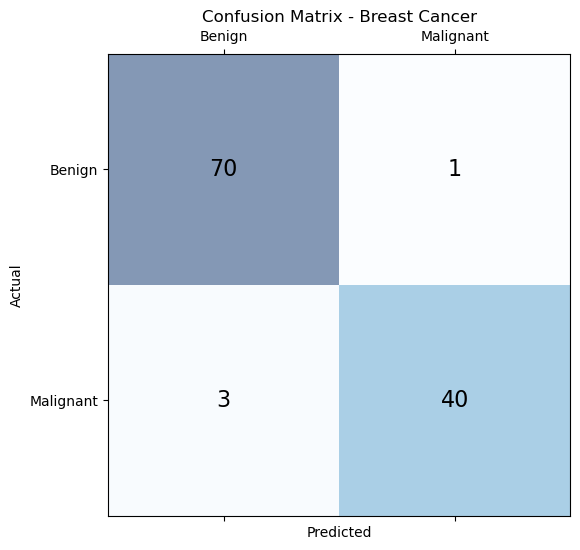

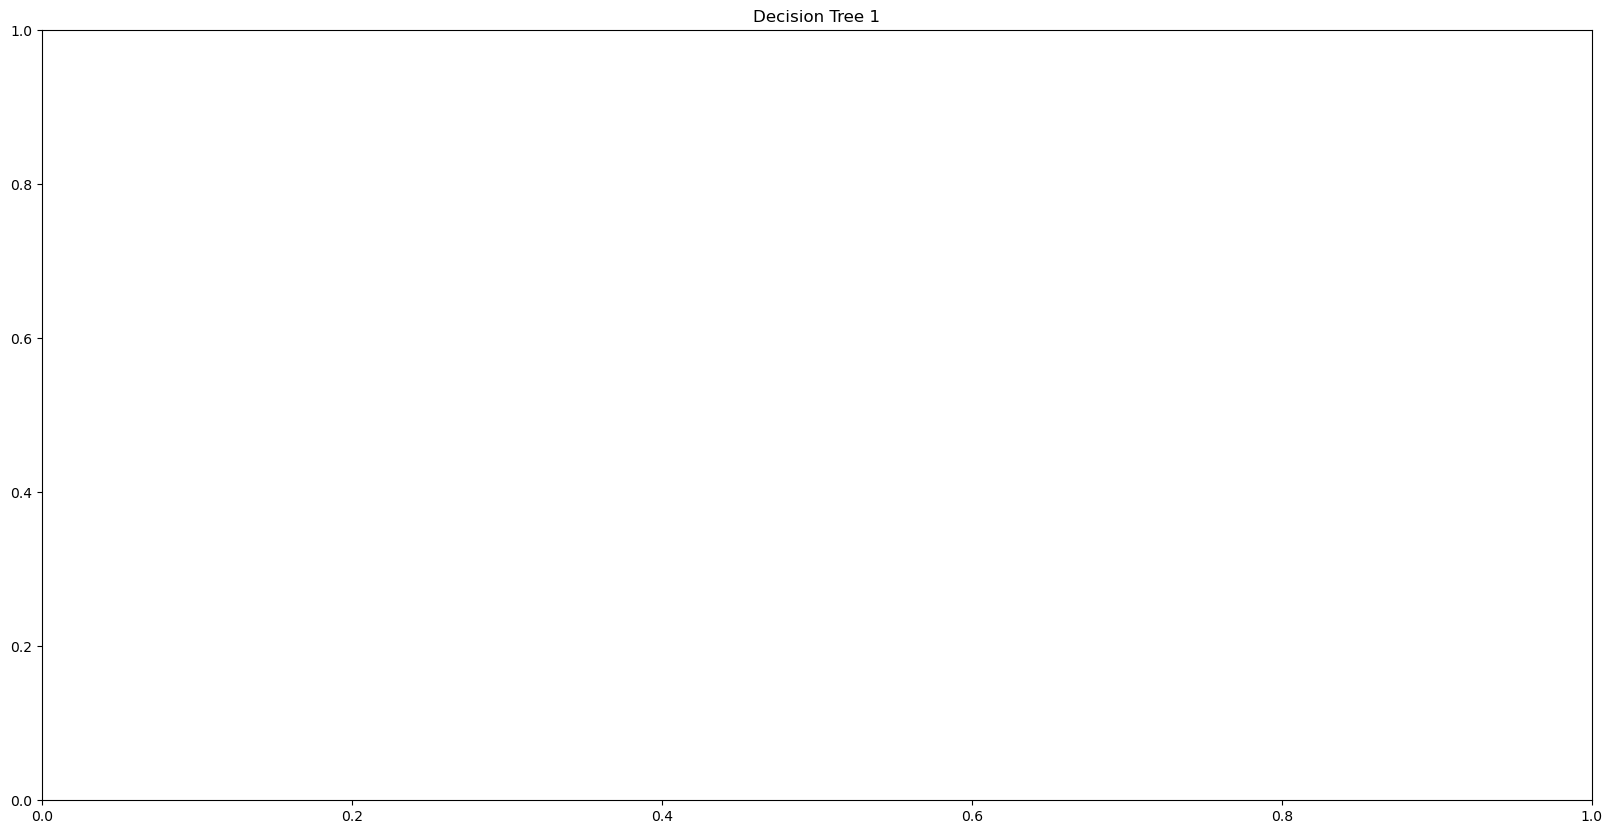

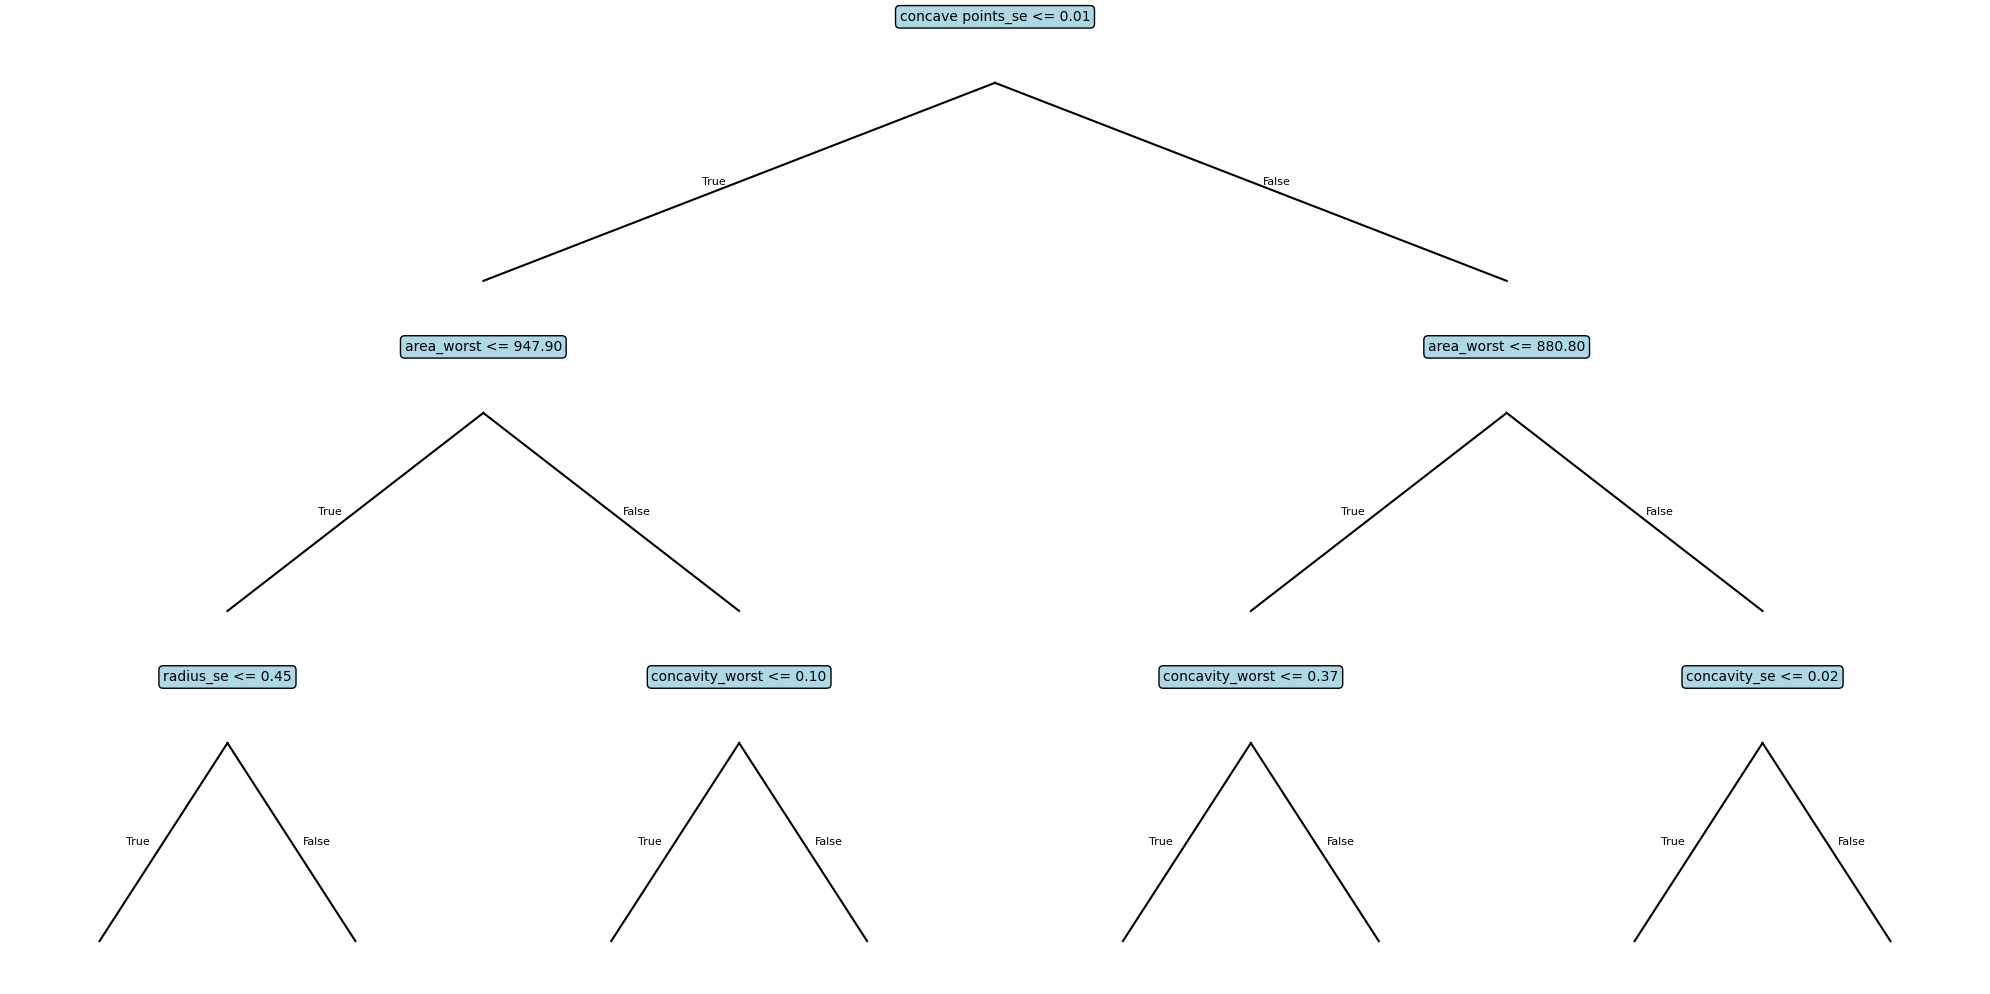

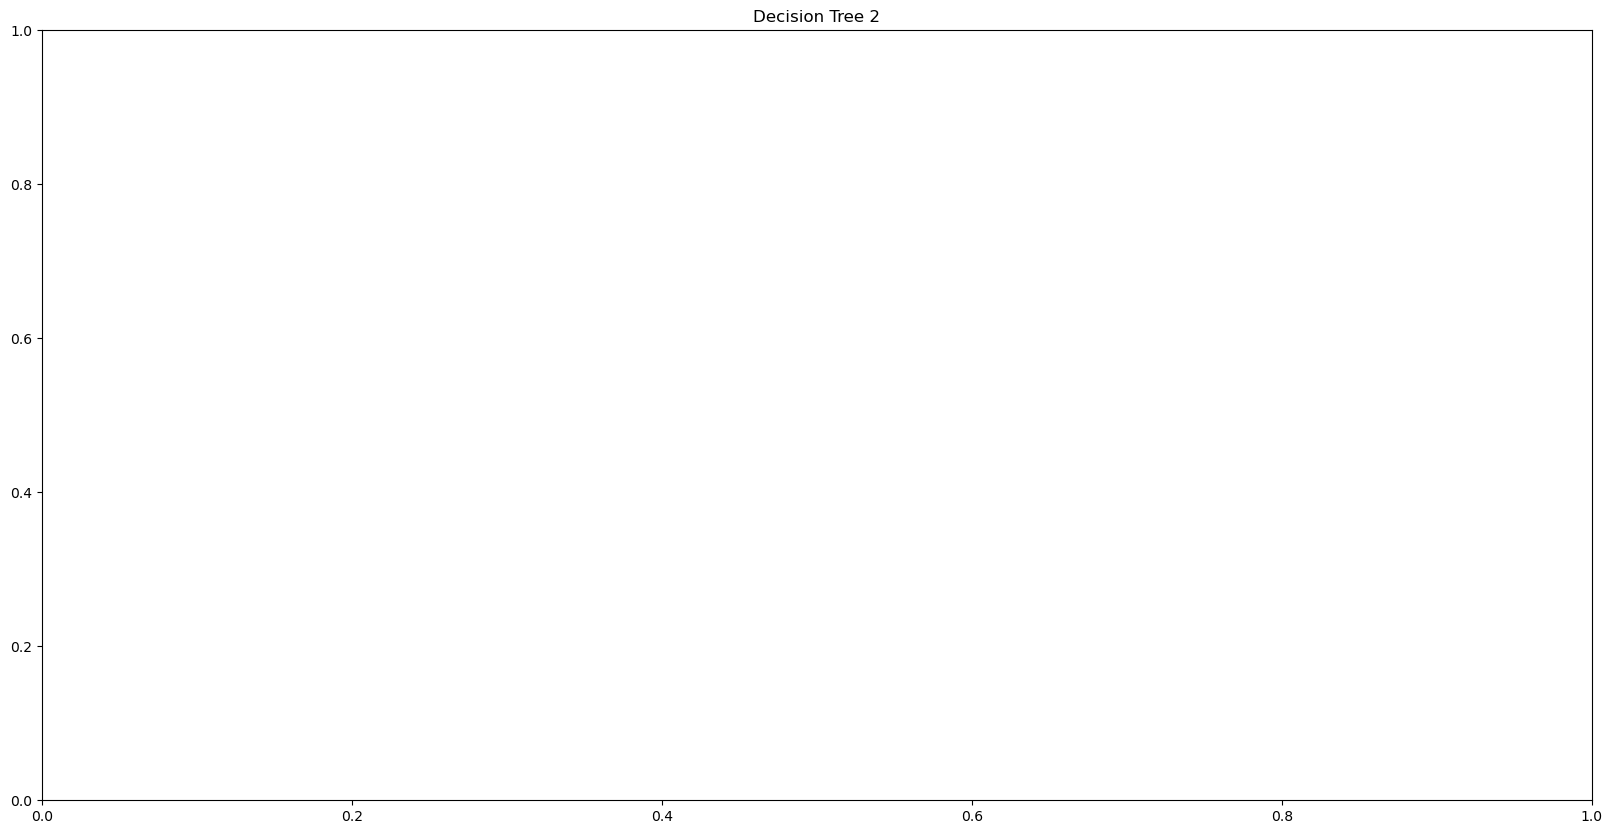

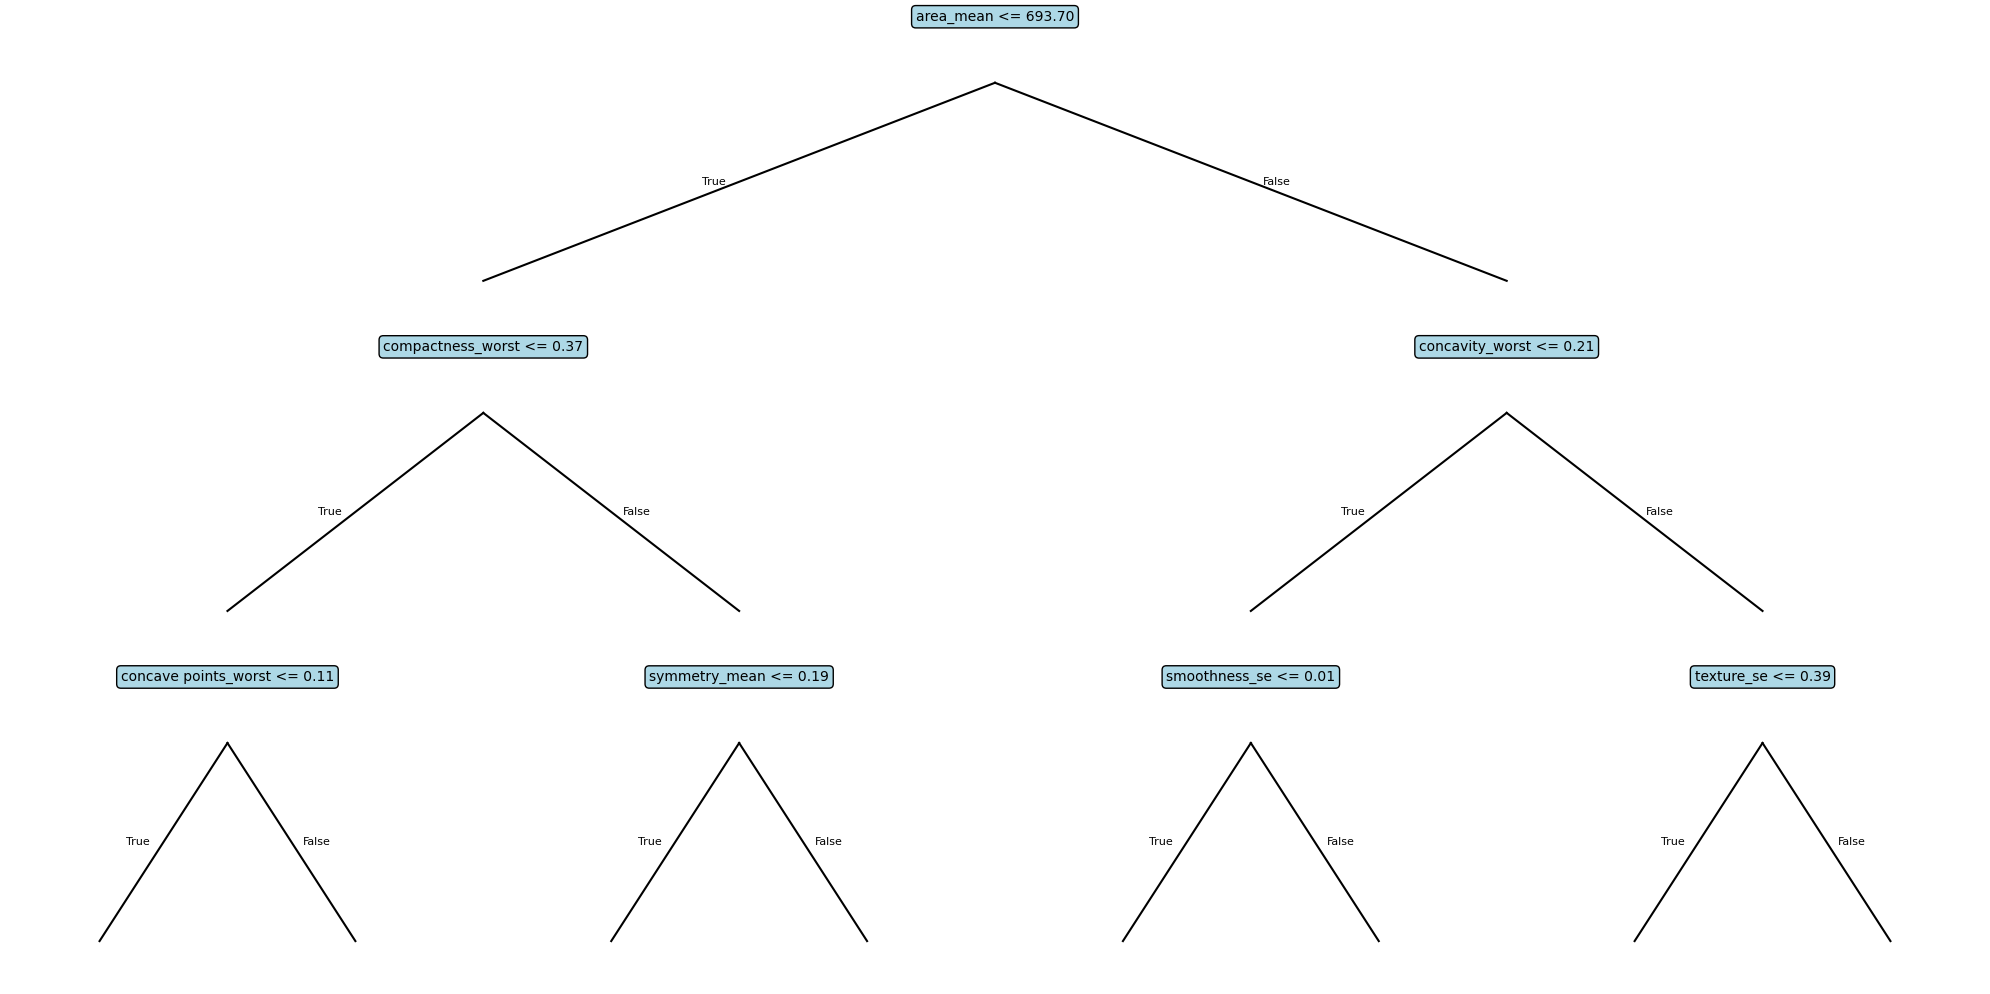

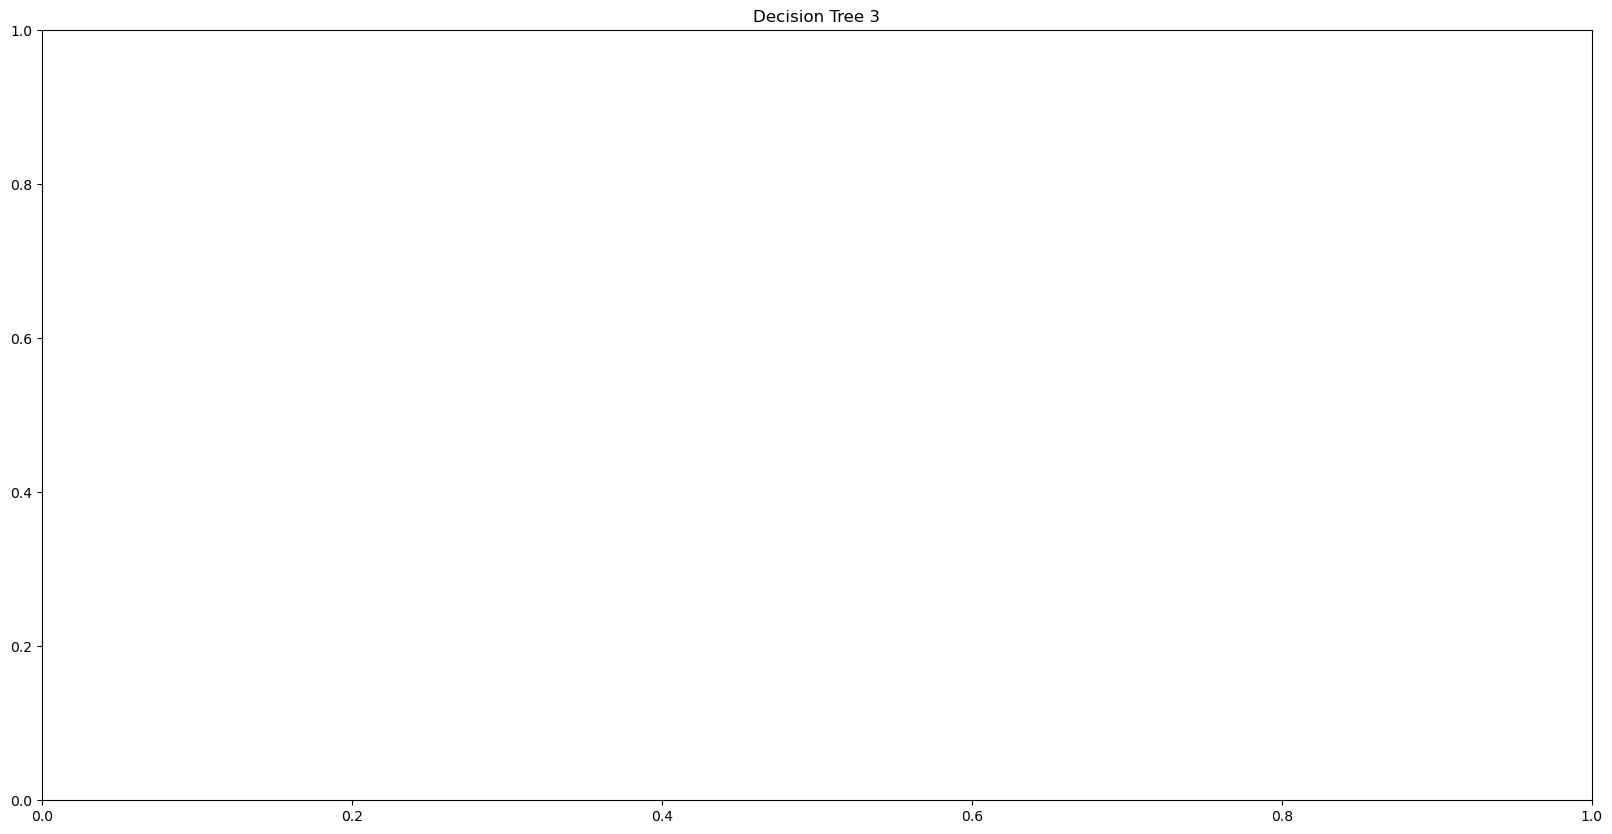

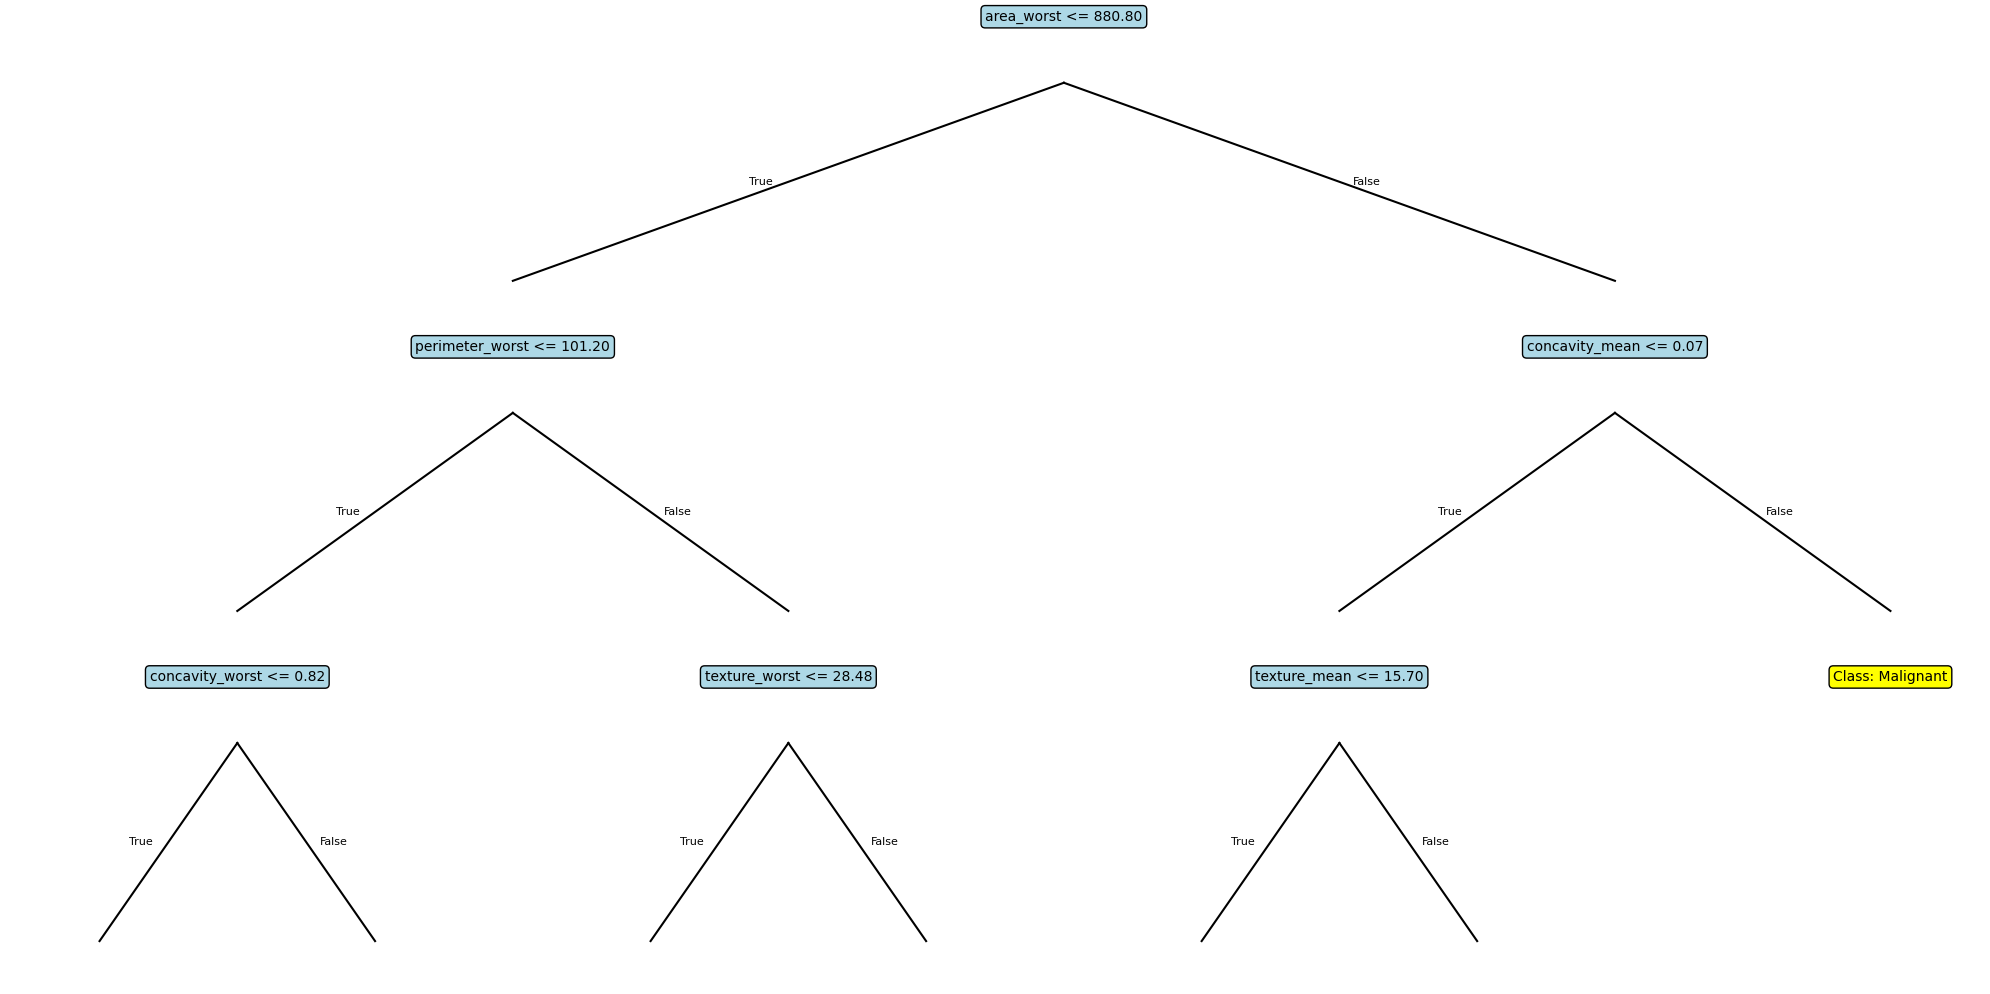

In [119]:
if __name__ == "__main__":
    exercise1()

Exercise 2: Random Forest on Wine Dataset with Hyperparameter Tuning

Model 1 with parameters: {'n_estimators': 3, 'max_depth': 3, 'max_features': 'sqrt'}
Accuracy: 0.9167
Confusion Matrix:
[[13  1  0]
 [ 0 14  0]
 [ 0  2  6]]


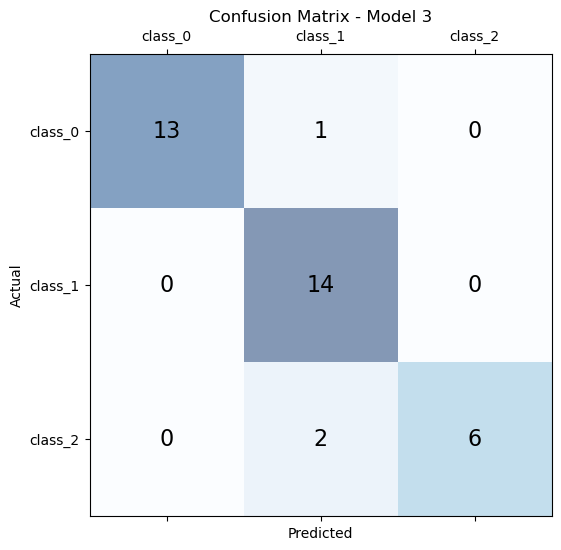

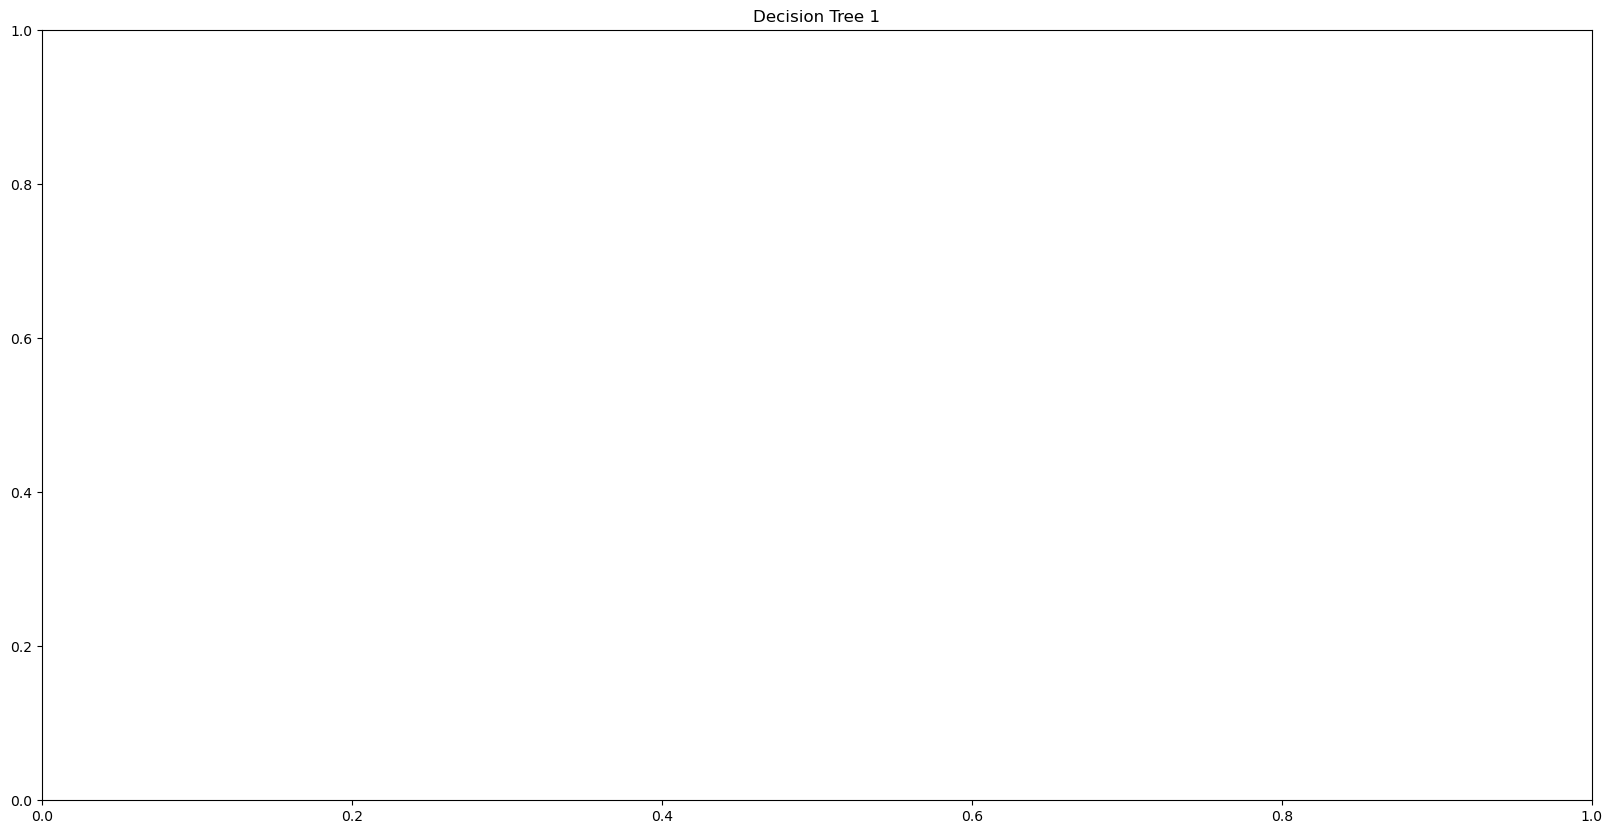

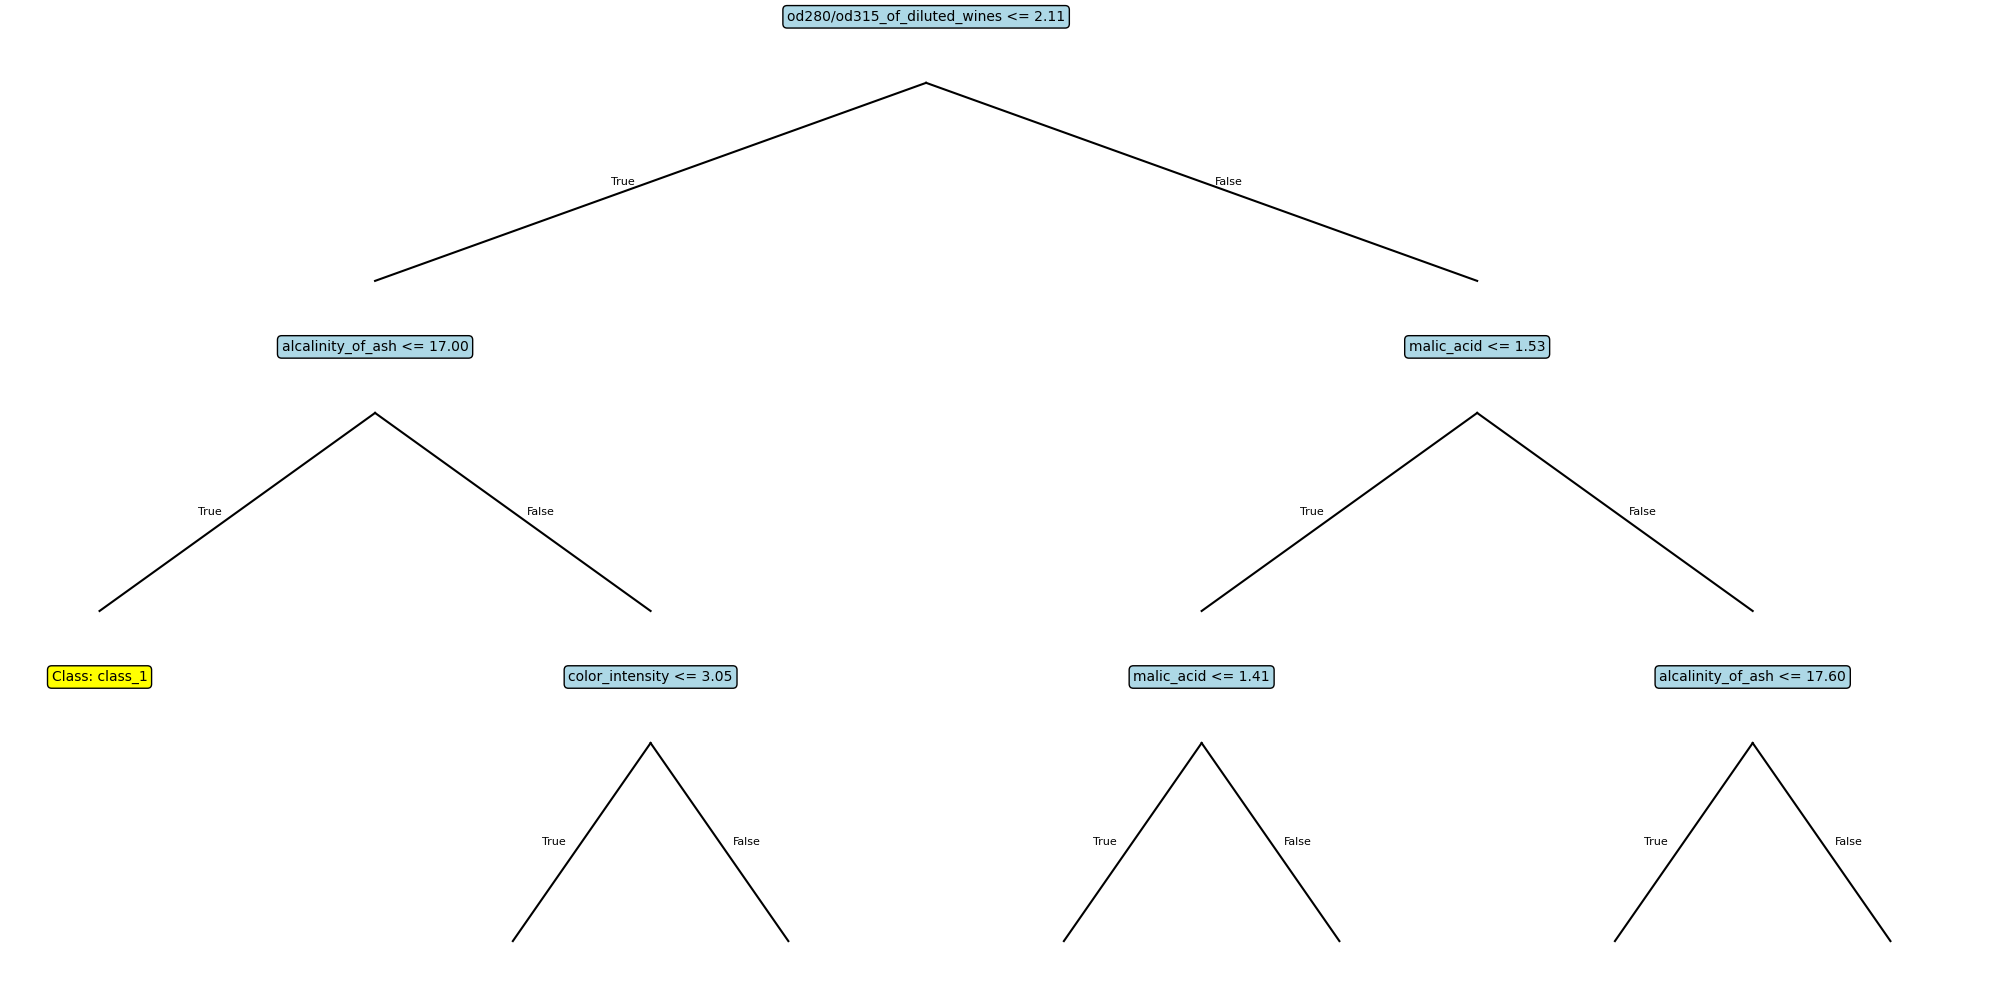

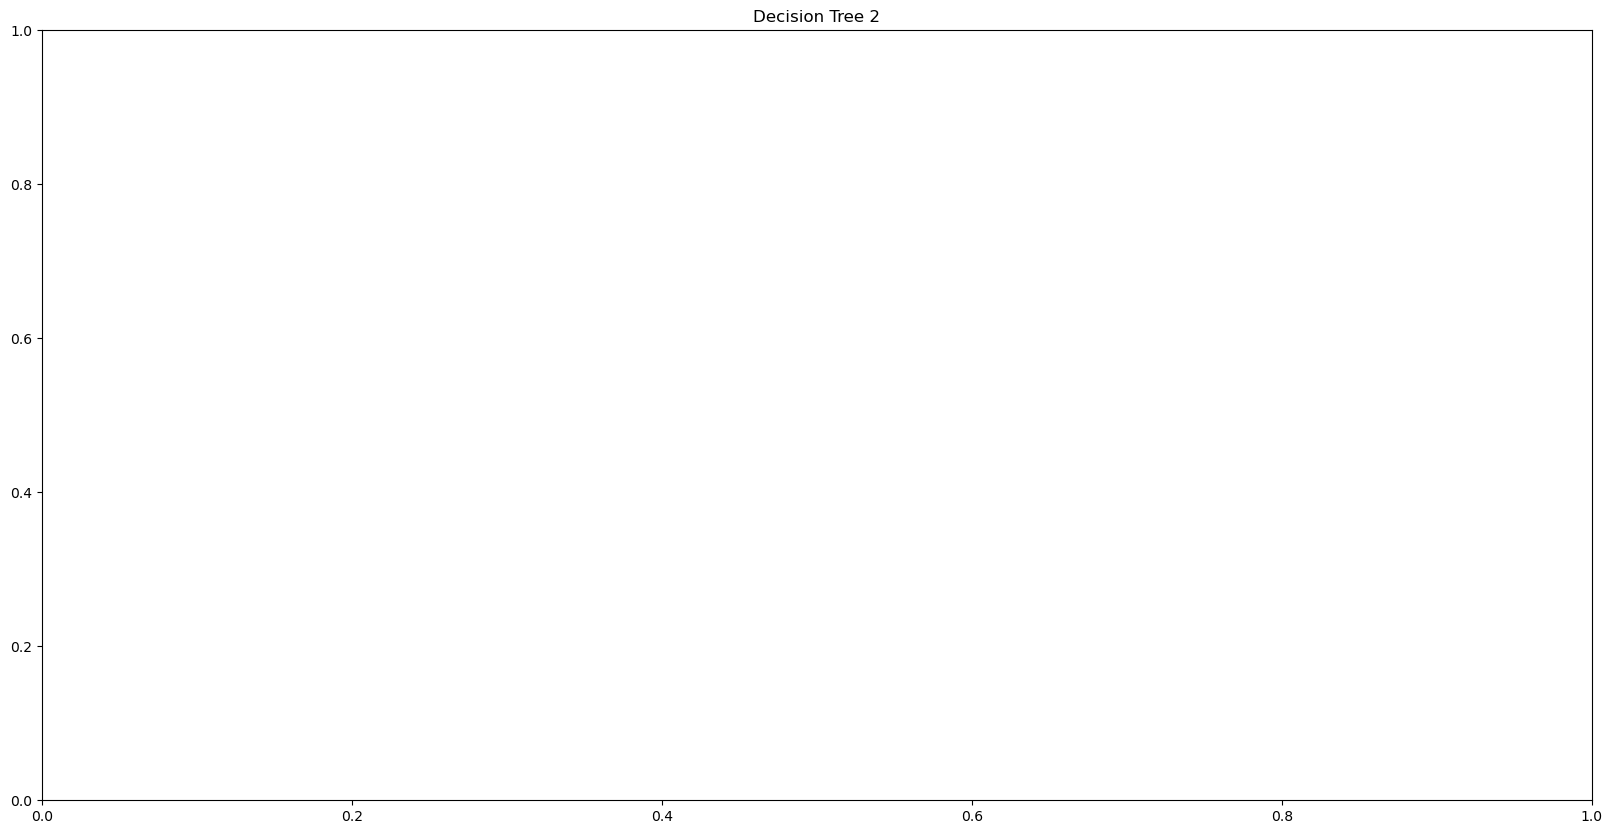

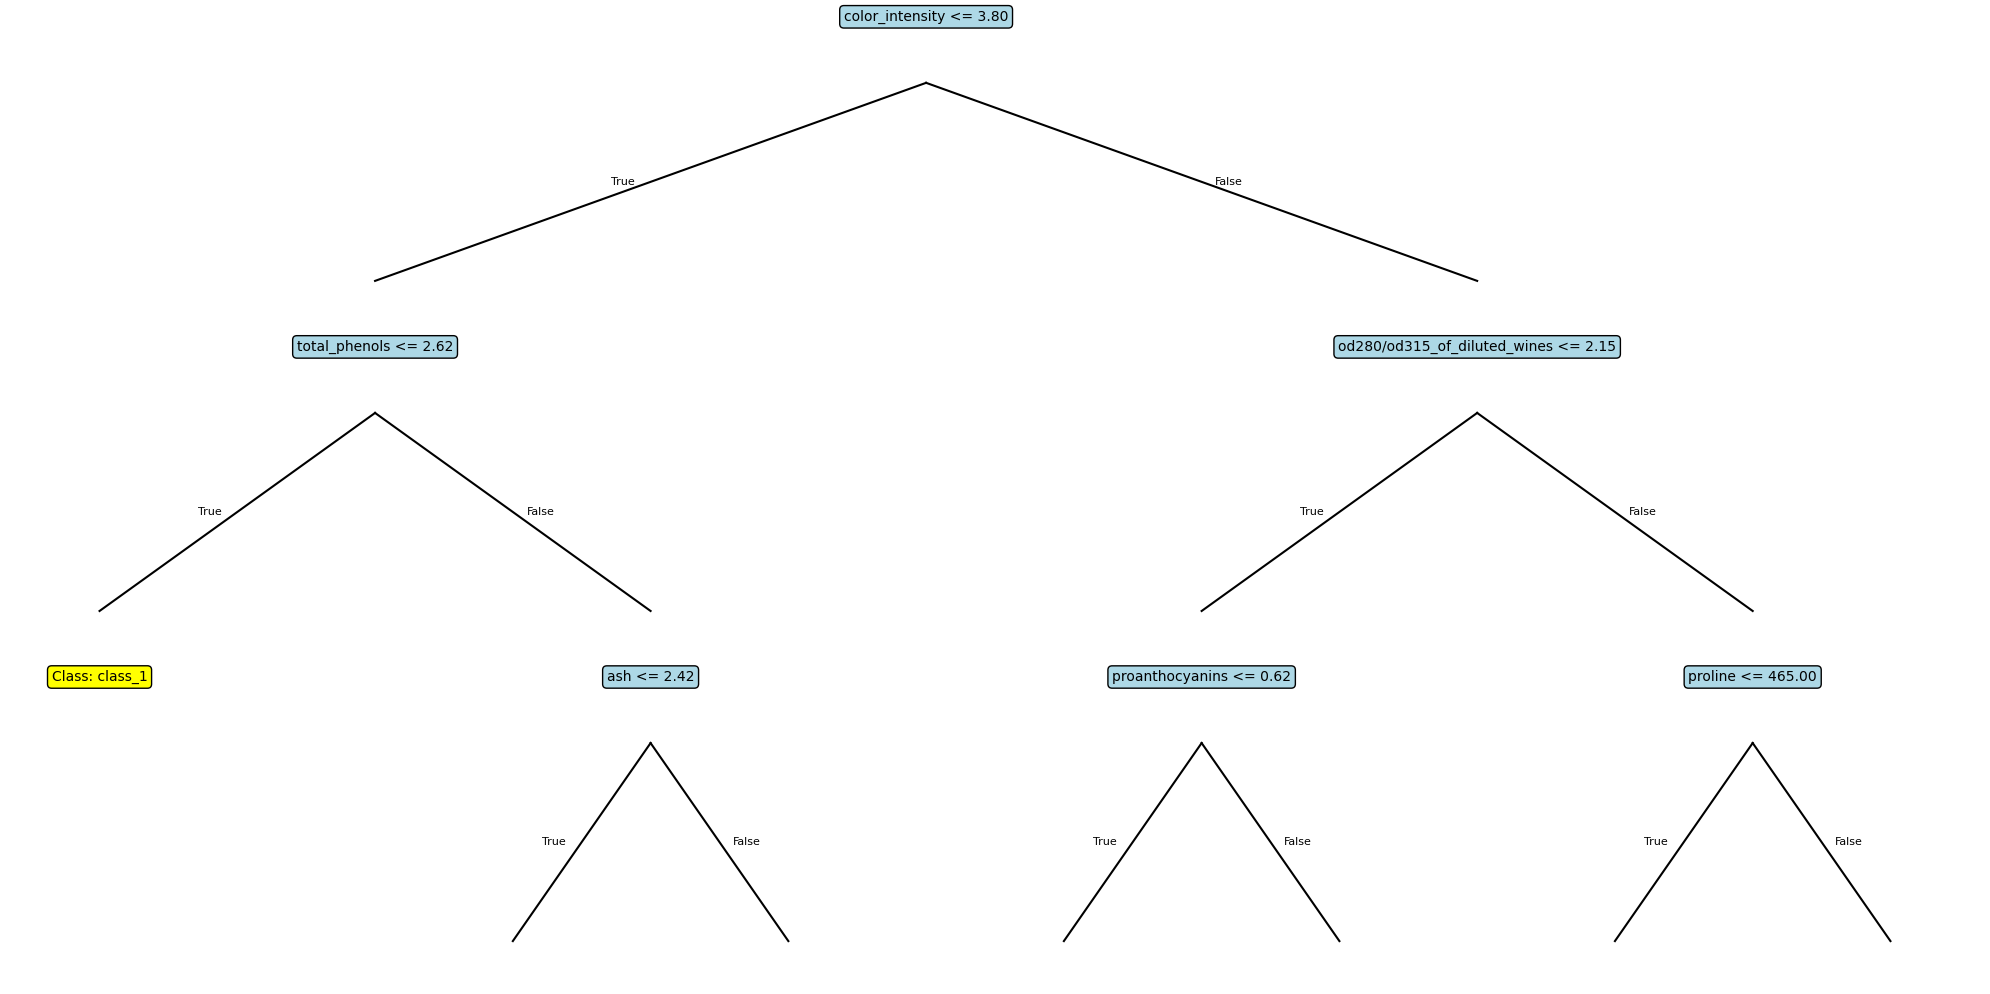

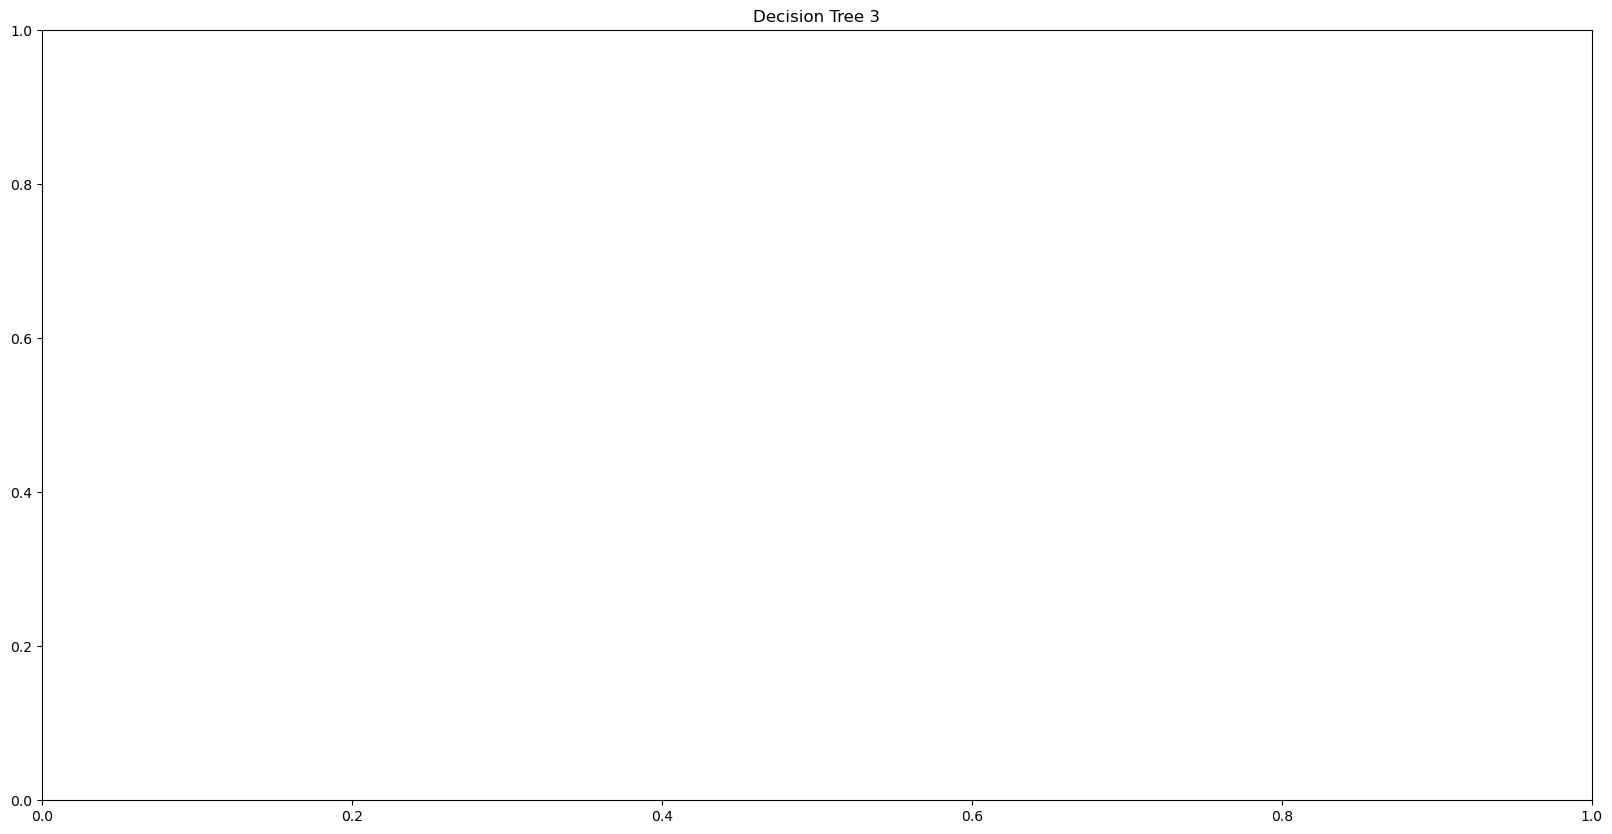

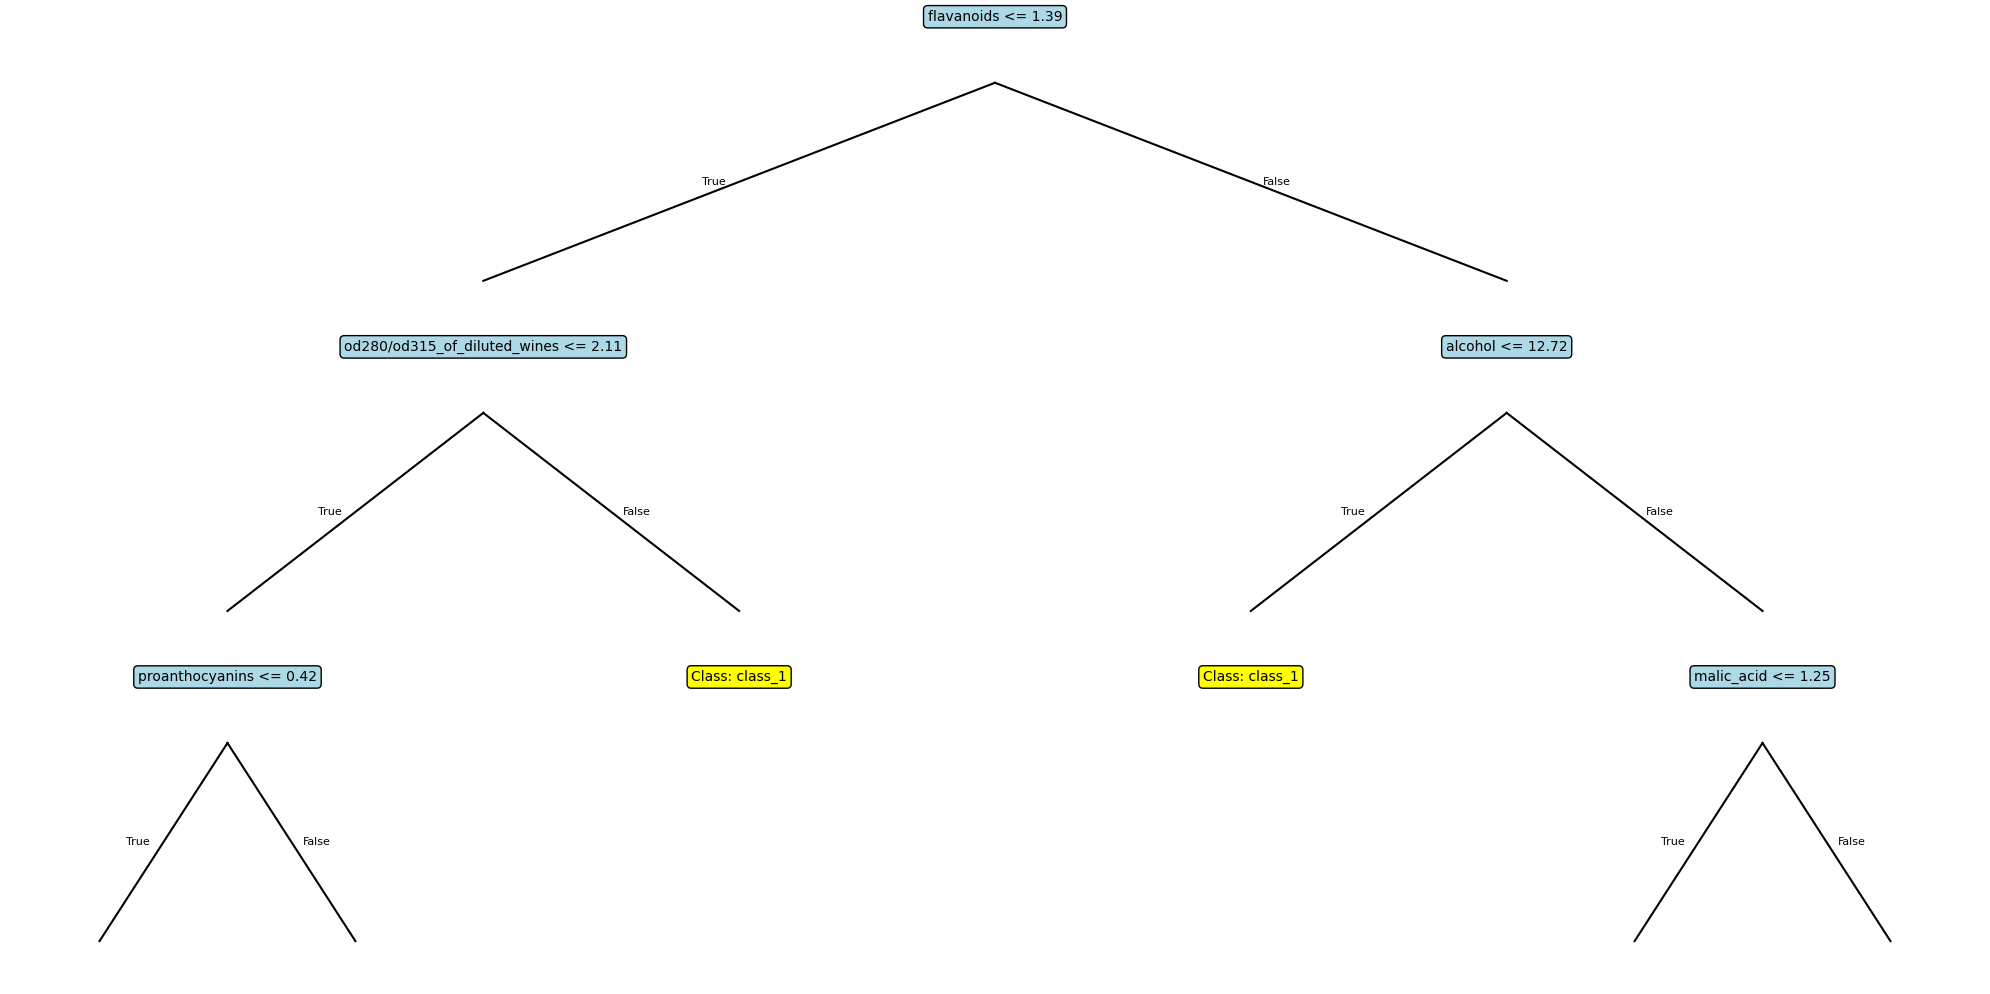


Model 2 with parameters: {'n_estimators': 5, 'max_depth': 5, 'max_features': 'sqrt'}
Accuracy: 0.9444
Confusion Matrix:
[[14  0  0]
 [ 2 12  0]
 [ 0  0  8]]


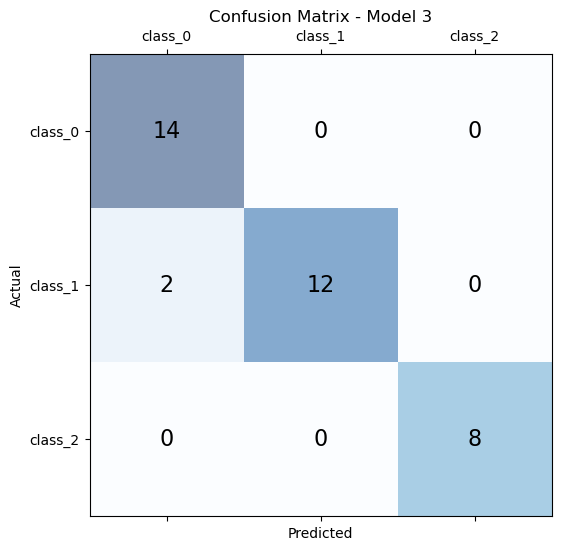

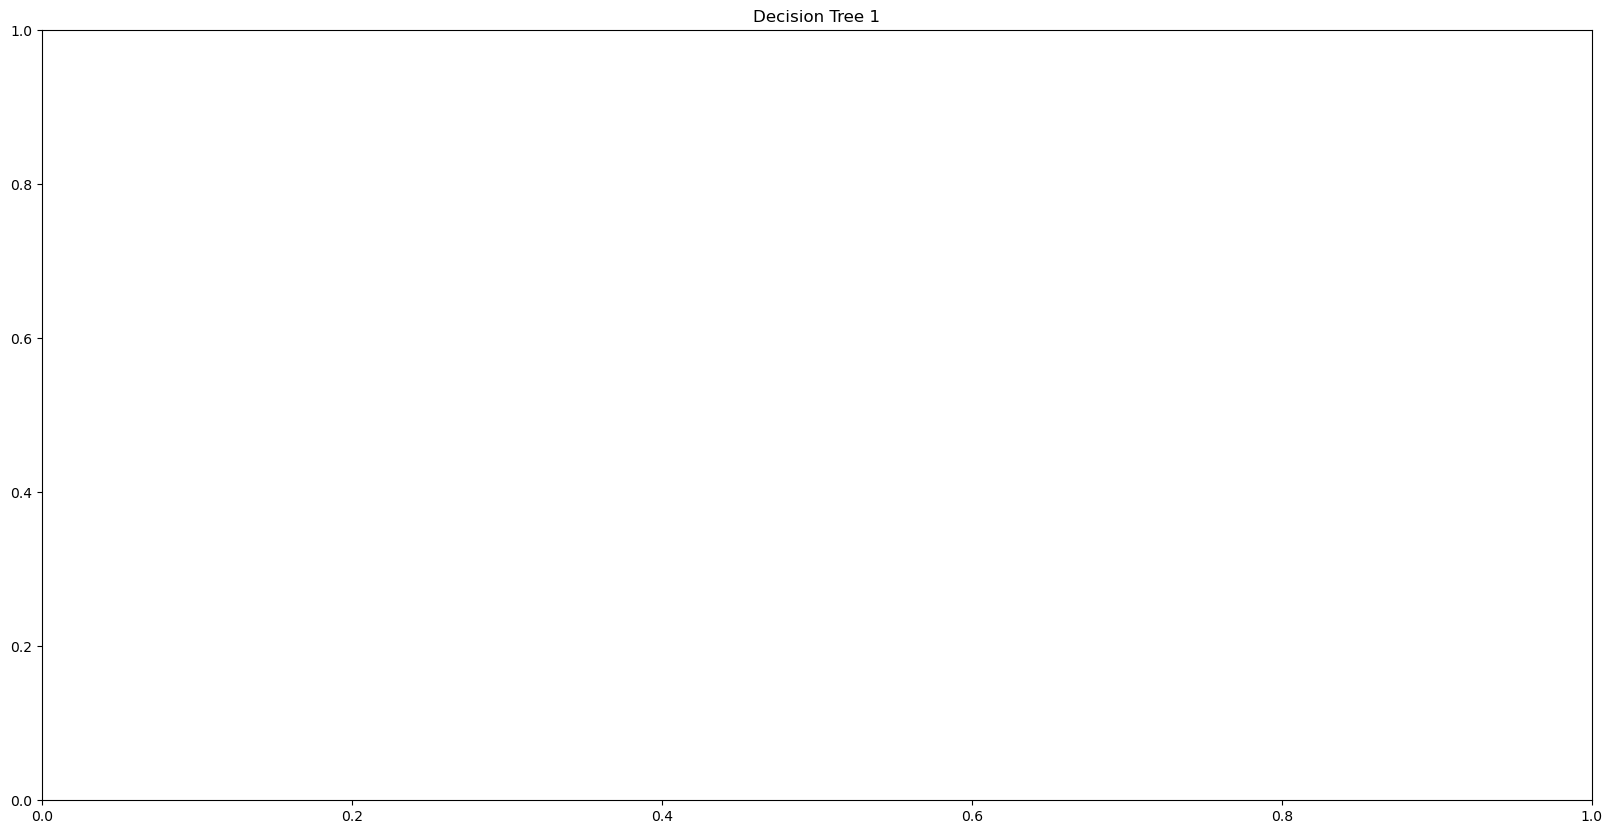

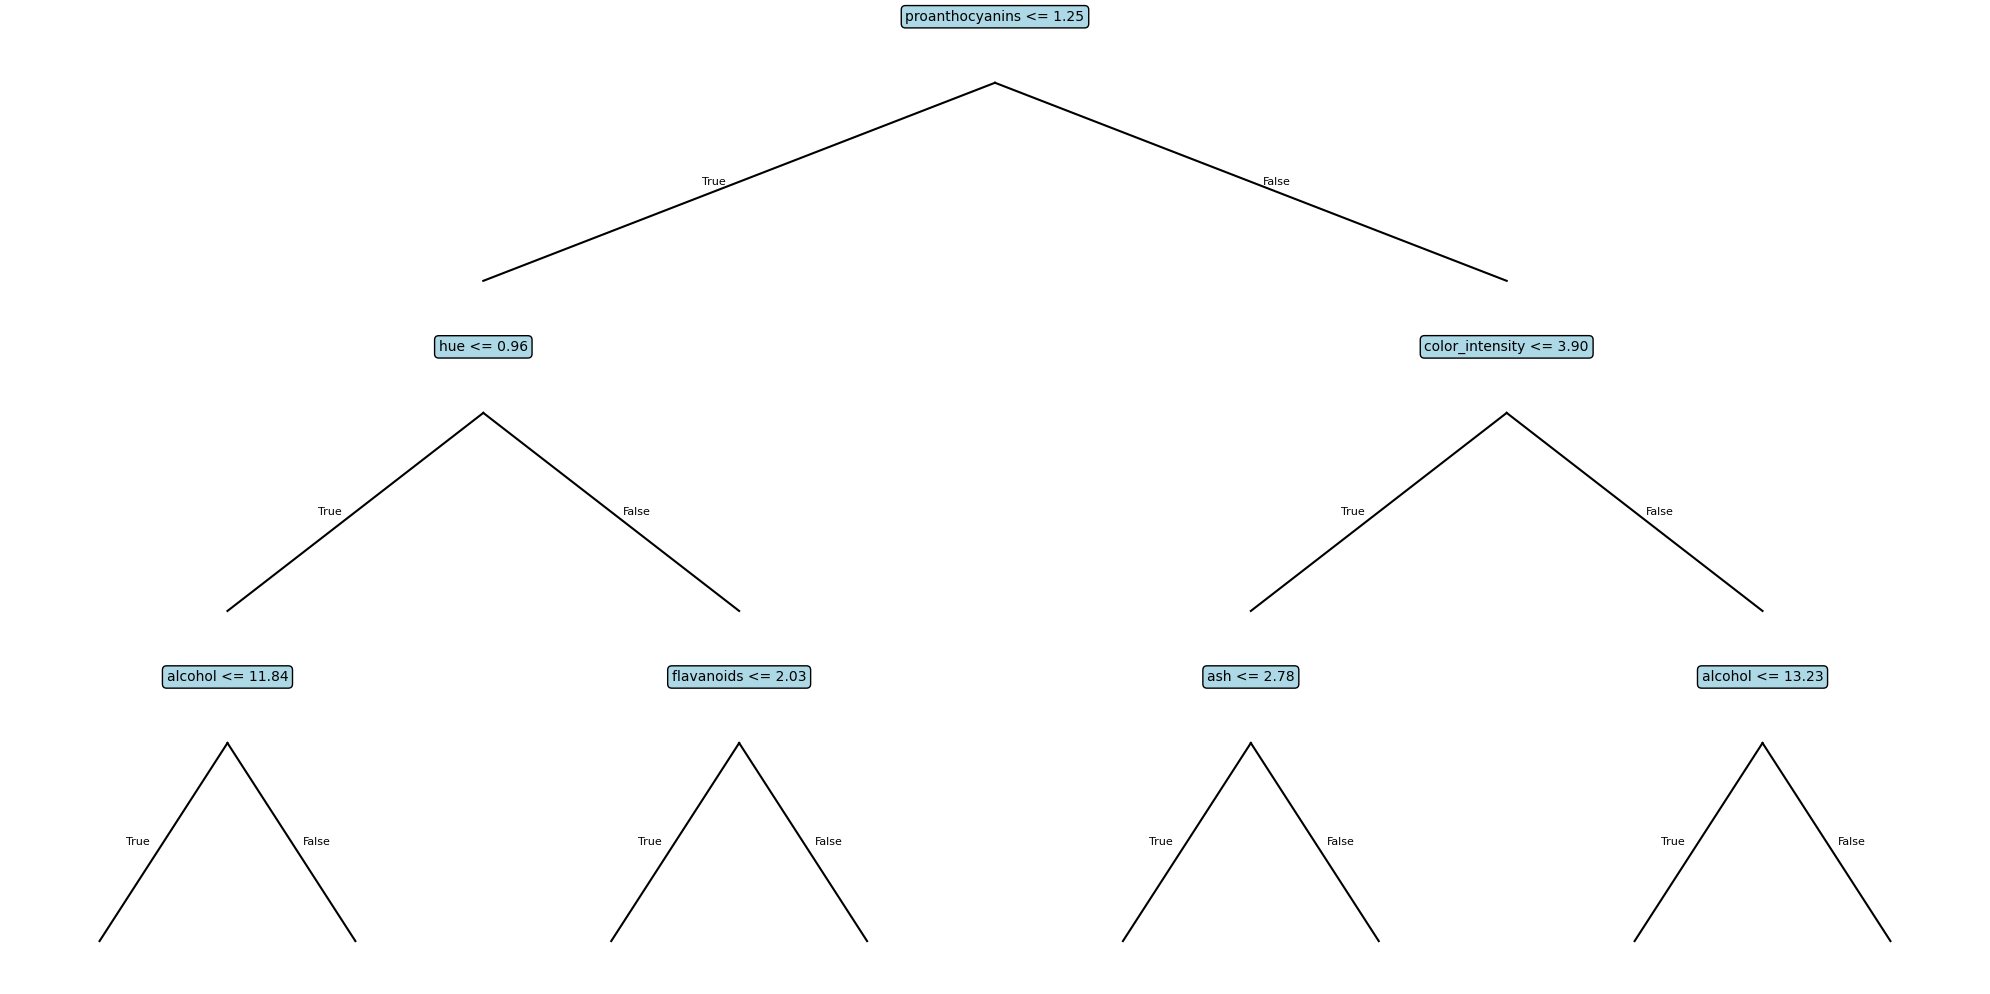

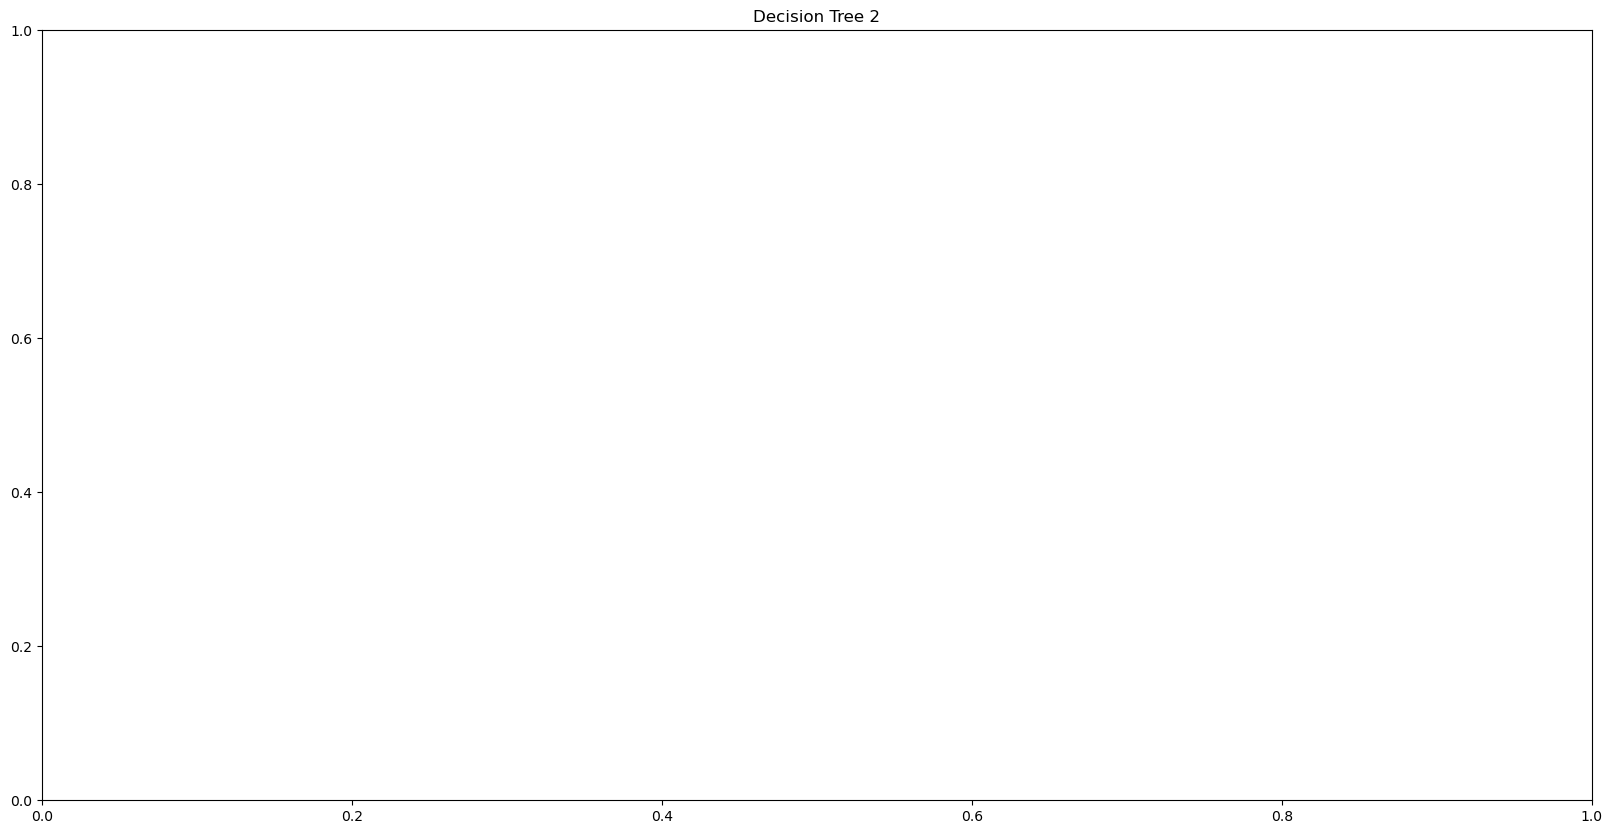

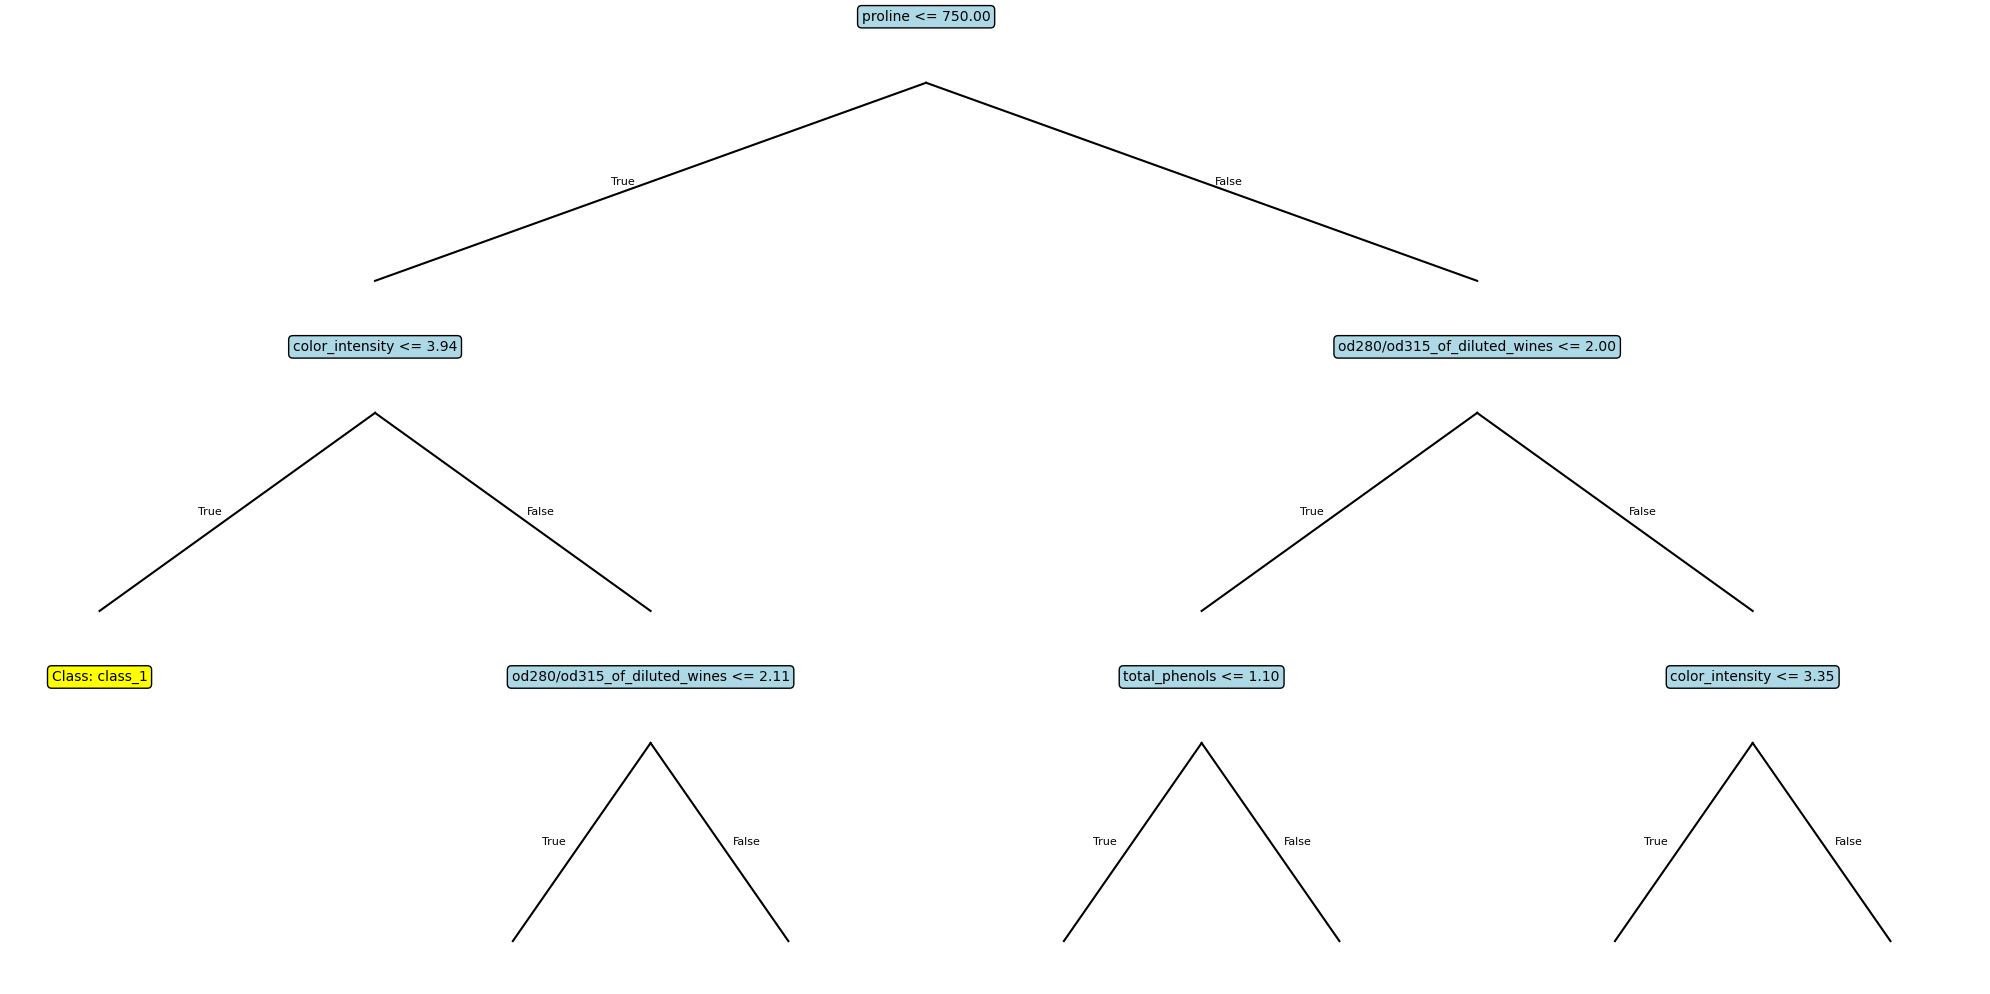

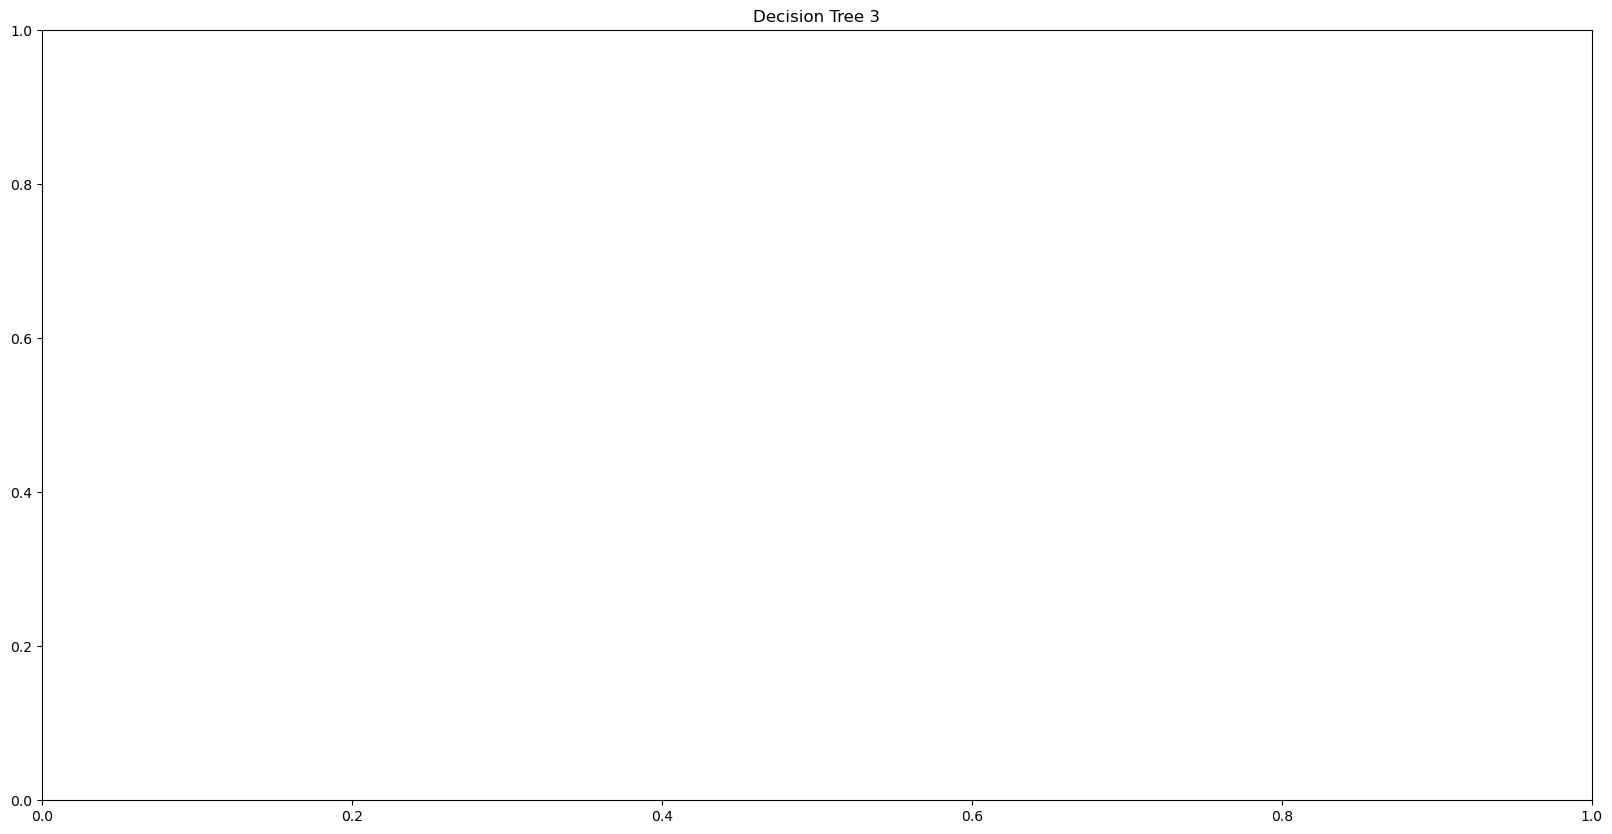

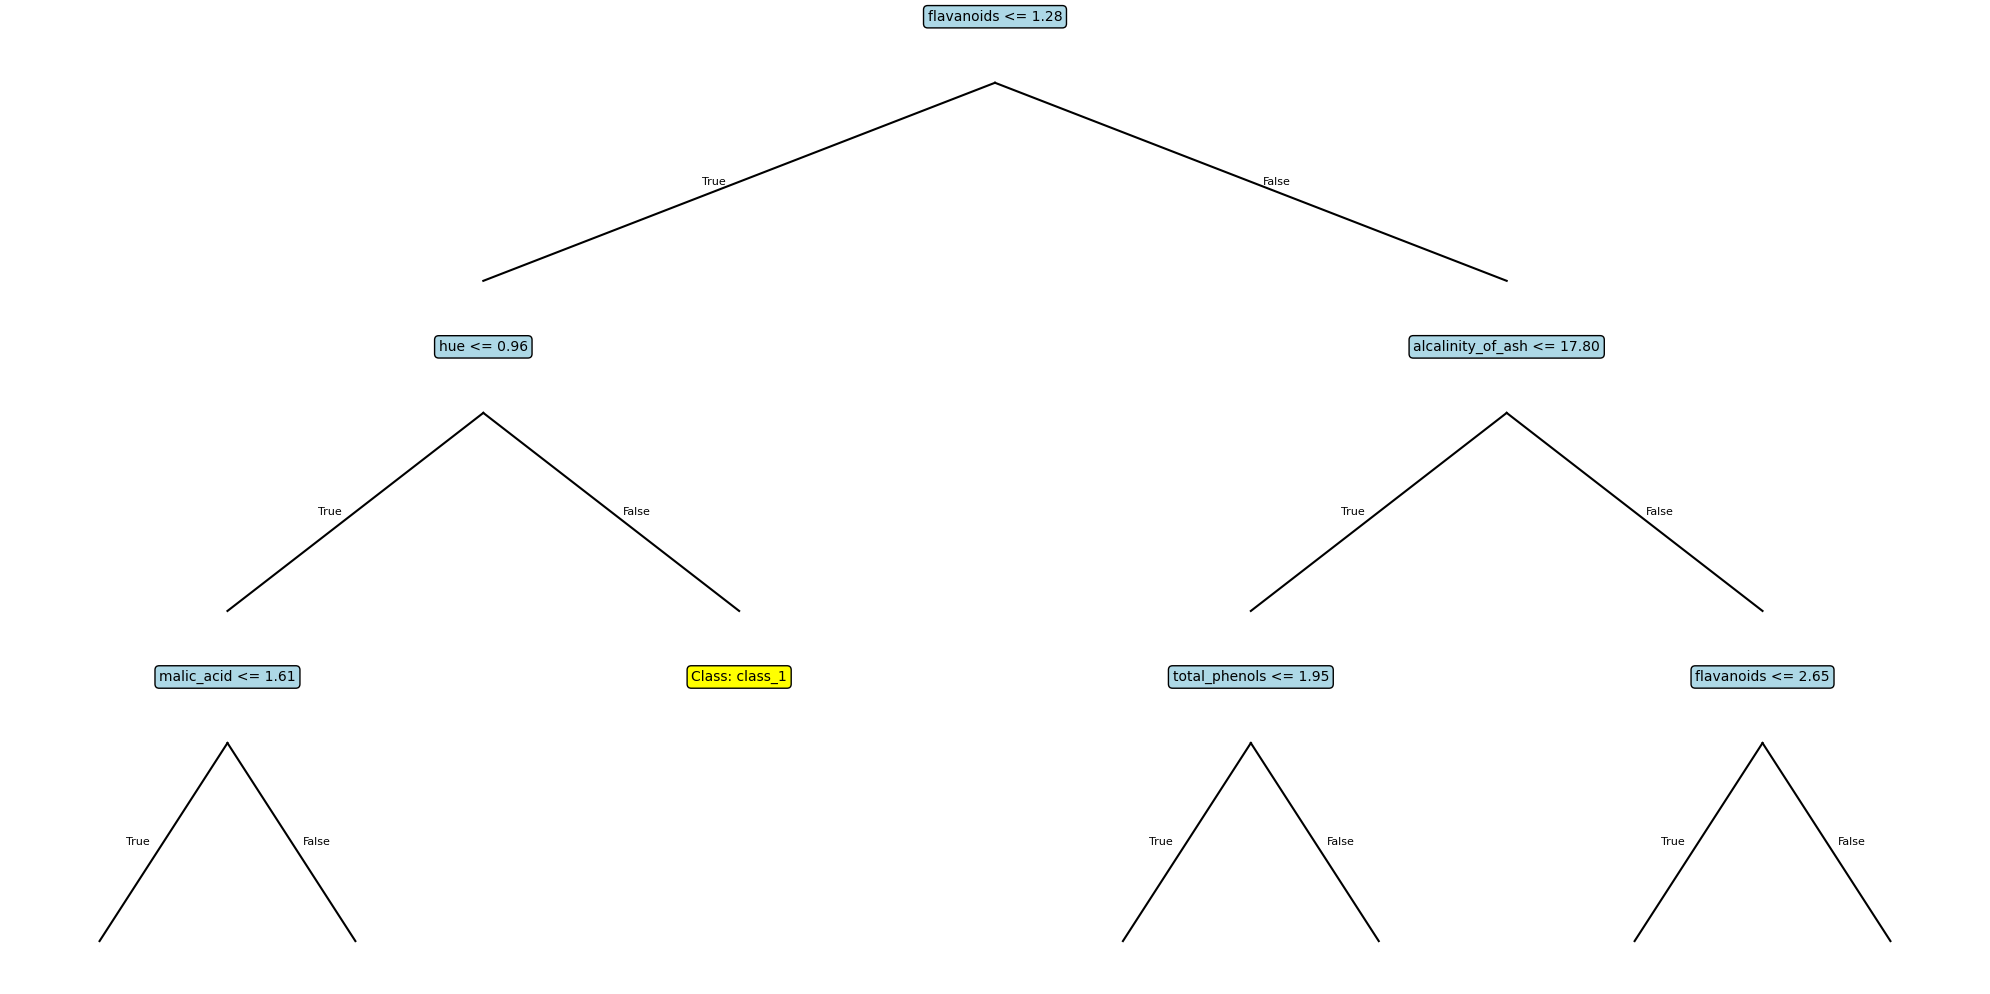

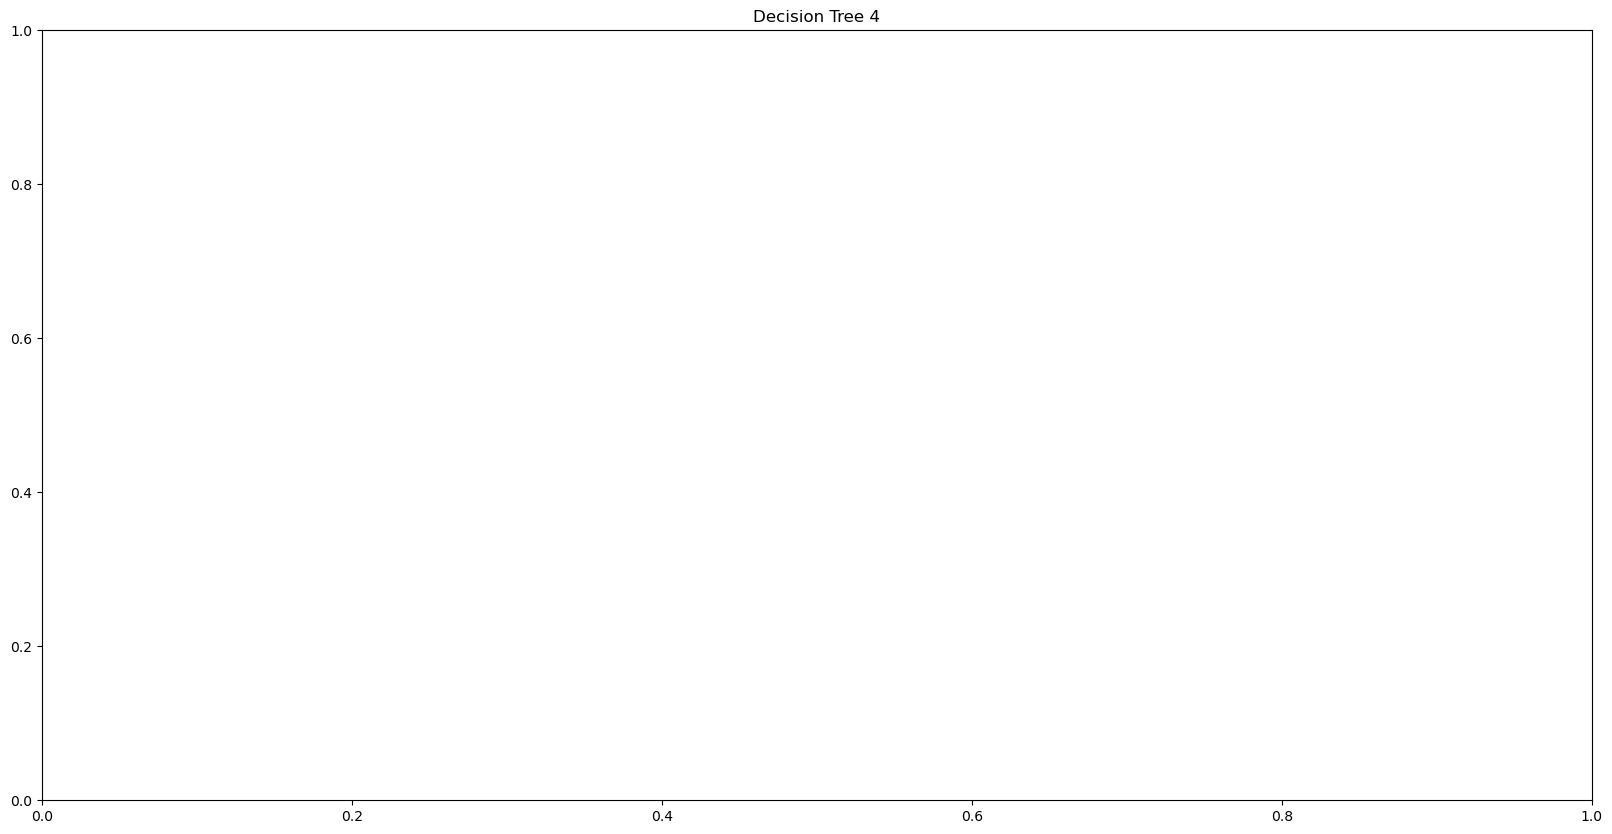

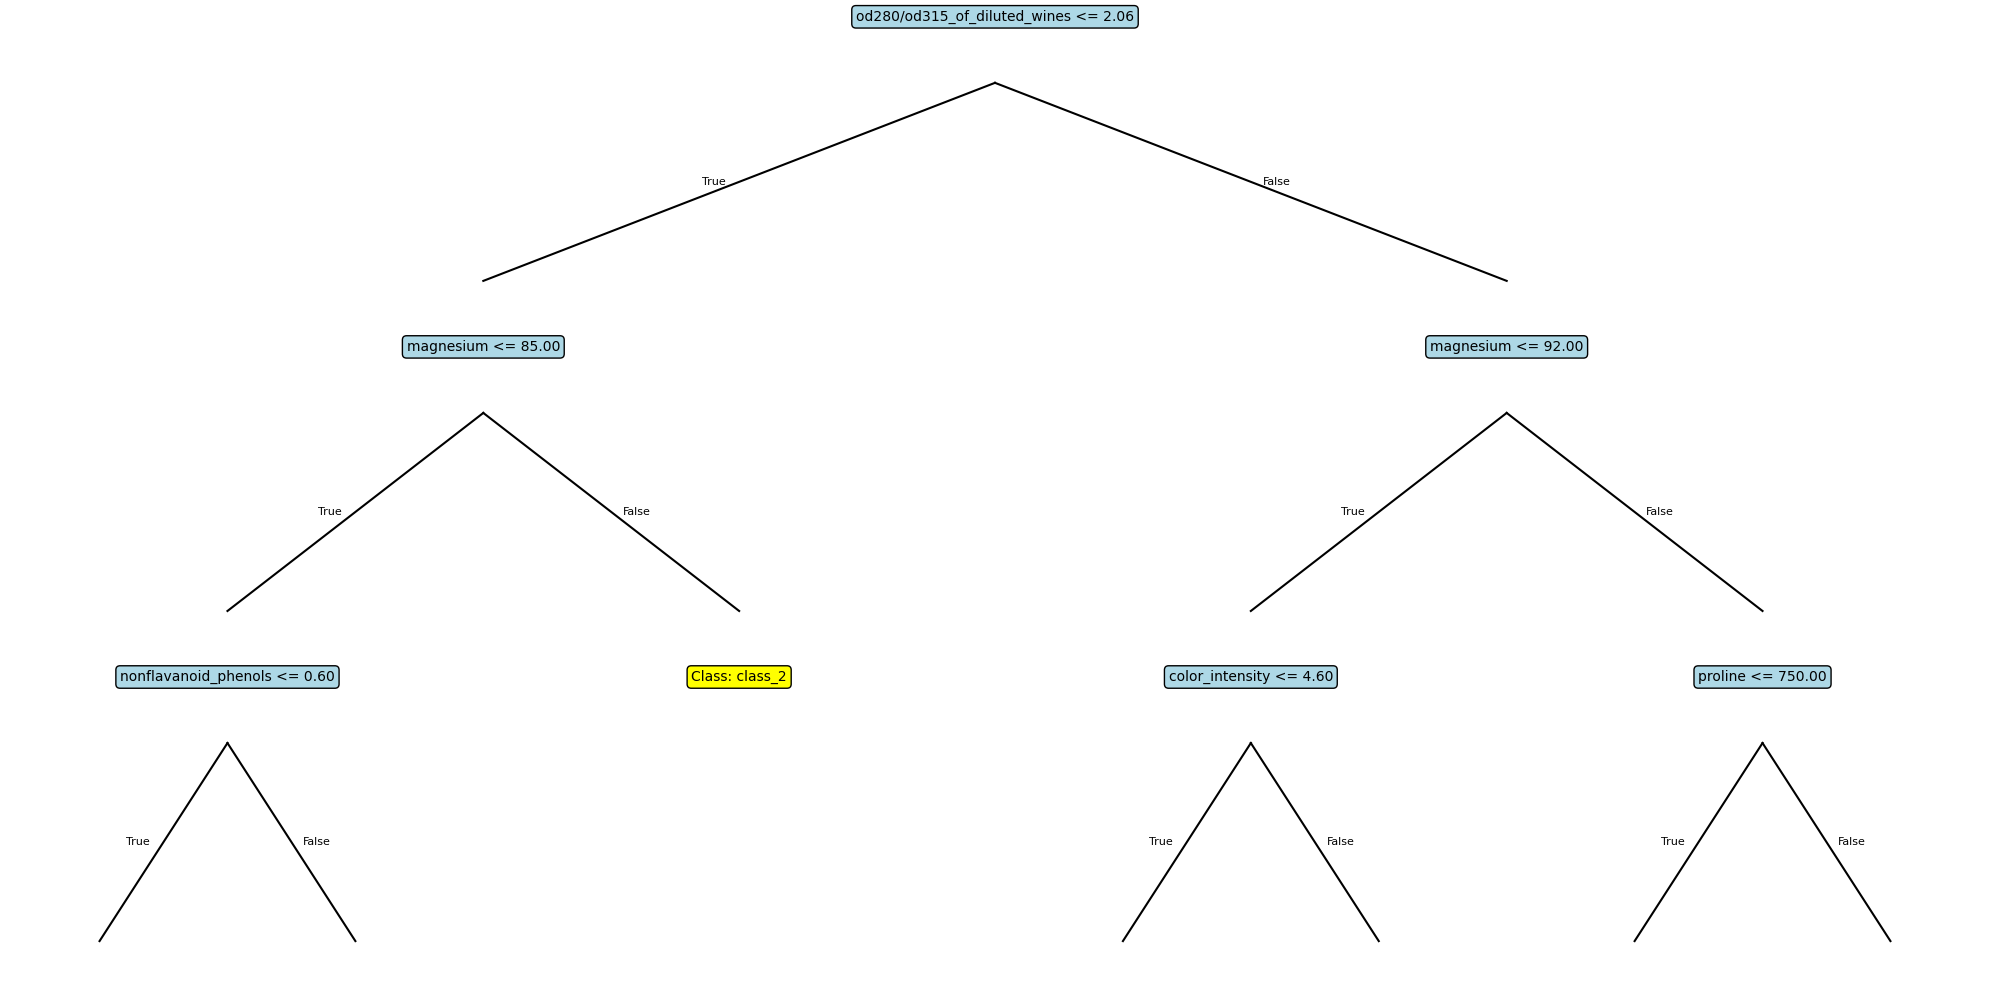

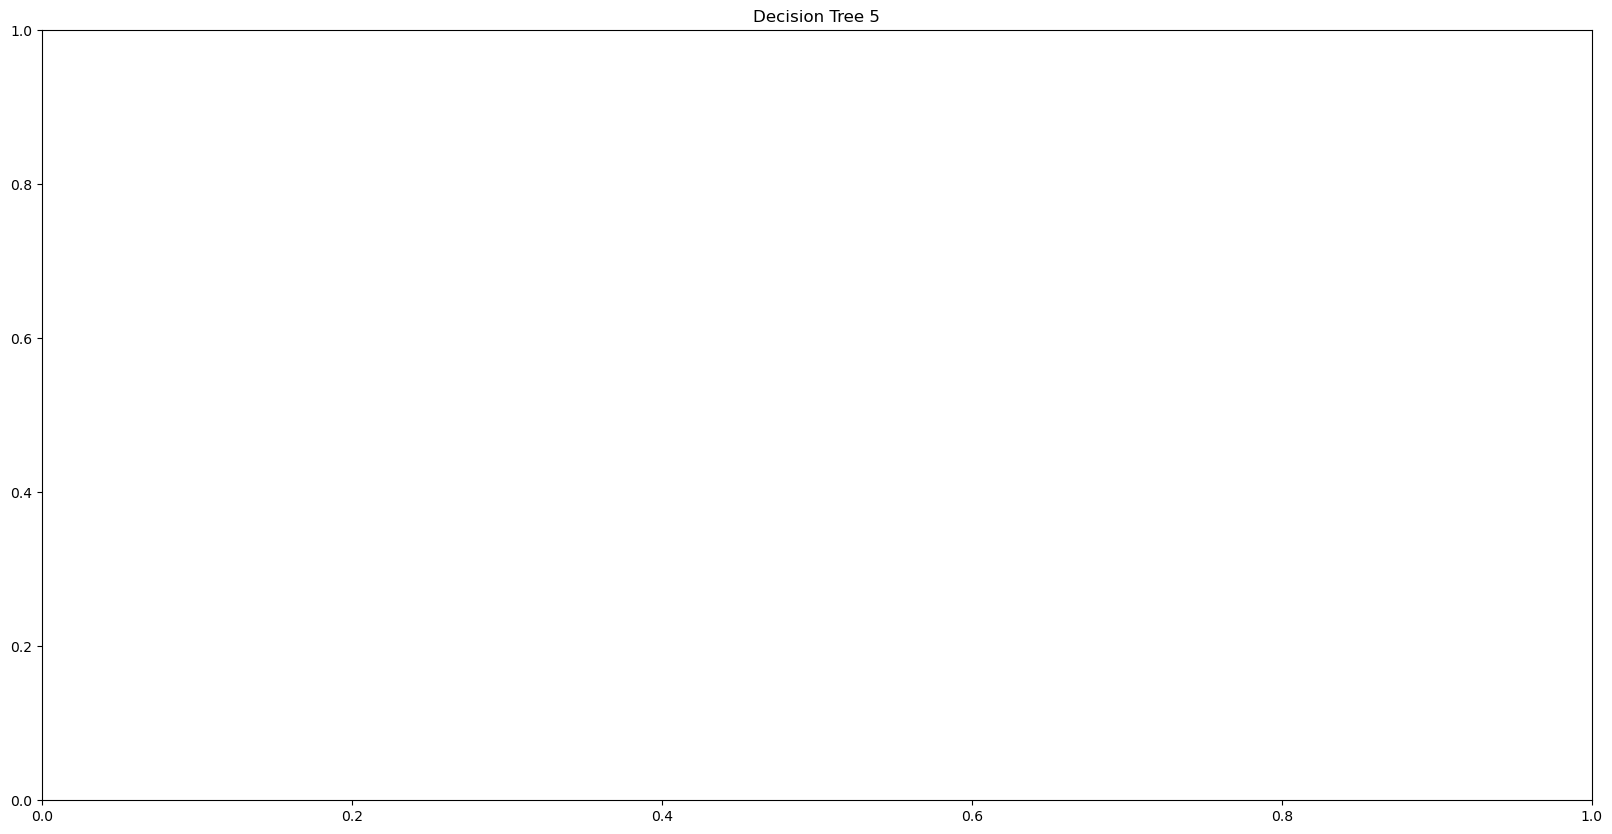

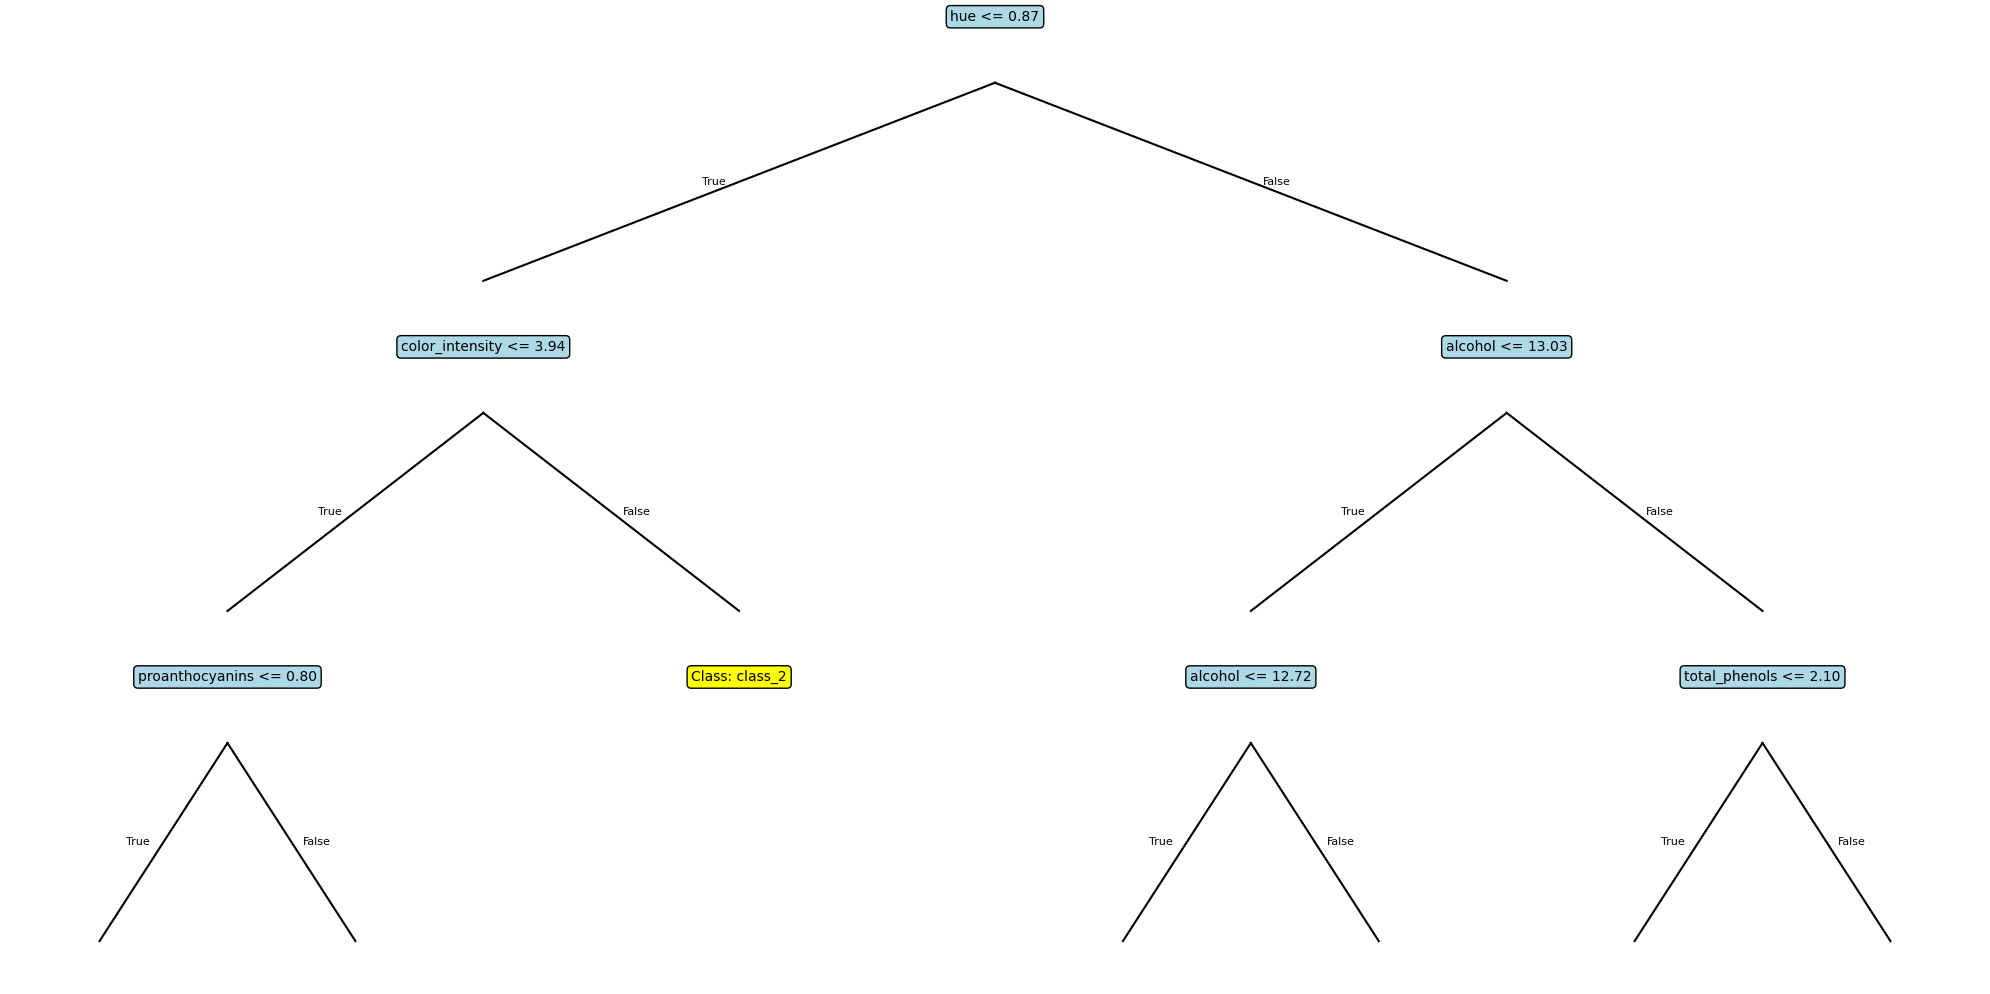


Model 3 with parameters: {'n_estimators': 7, 'max_depth': None, 'max_features': 0.5}
Accuracy: 0.9444
Confusion Matrix:
[[14  0  0]
 [ 1 13  0]
 [ 0  1  7]]


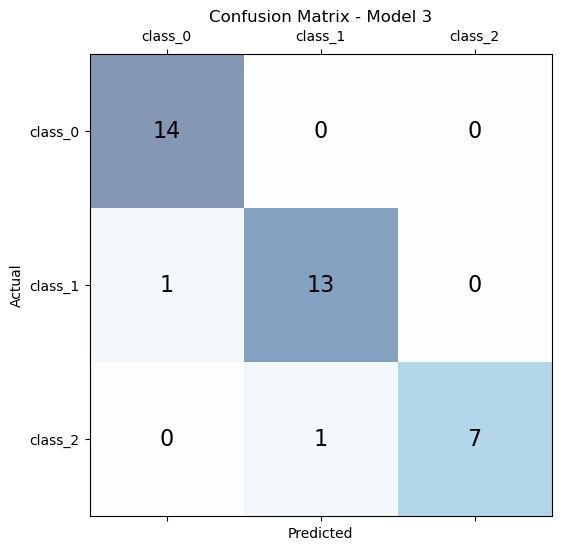

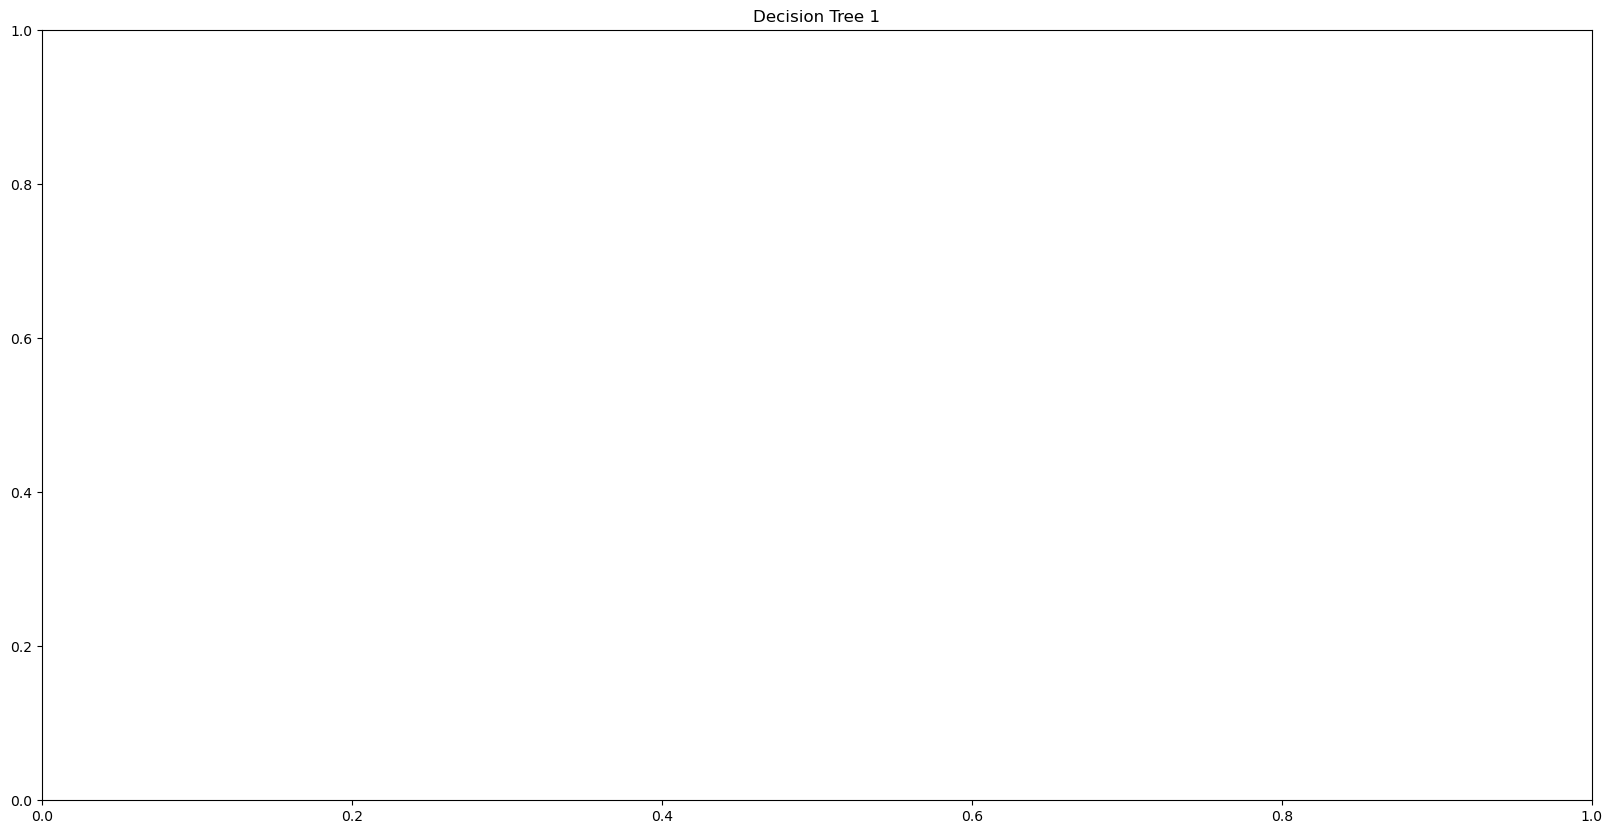

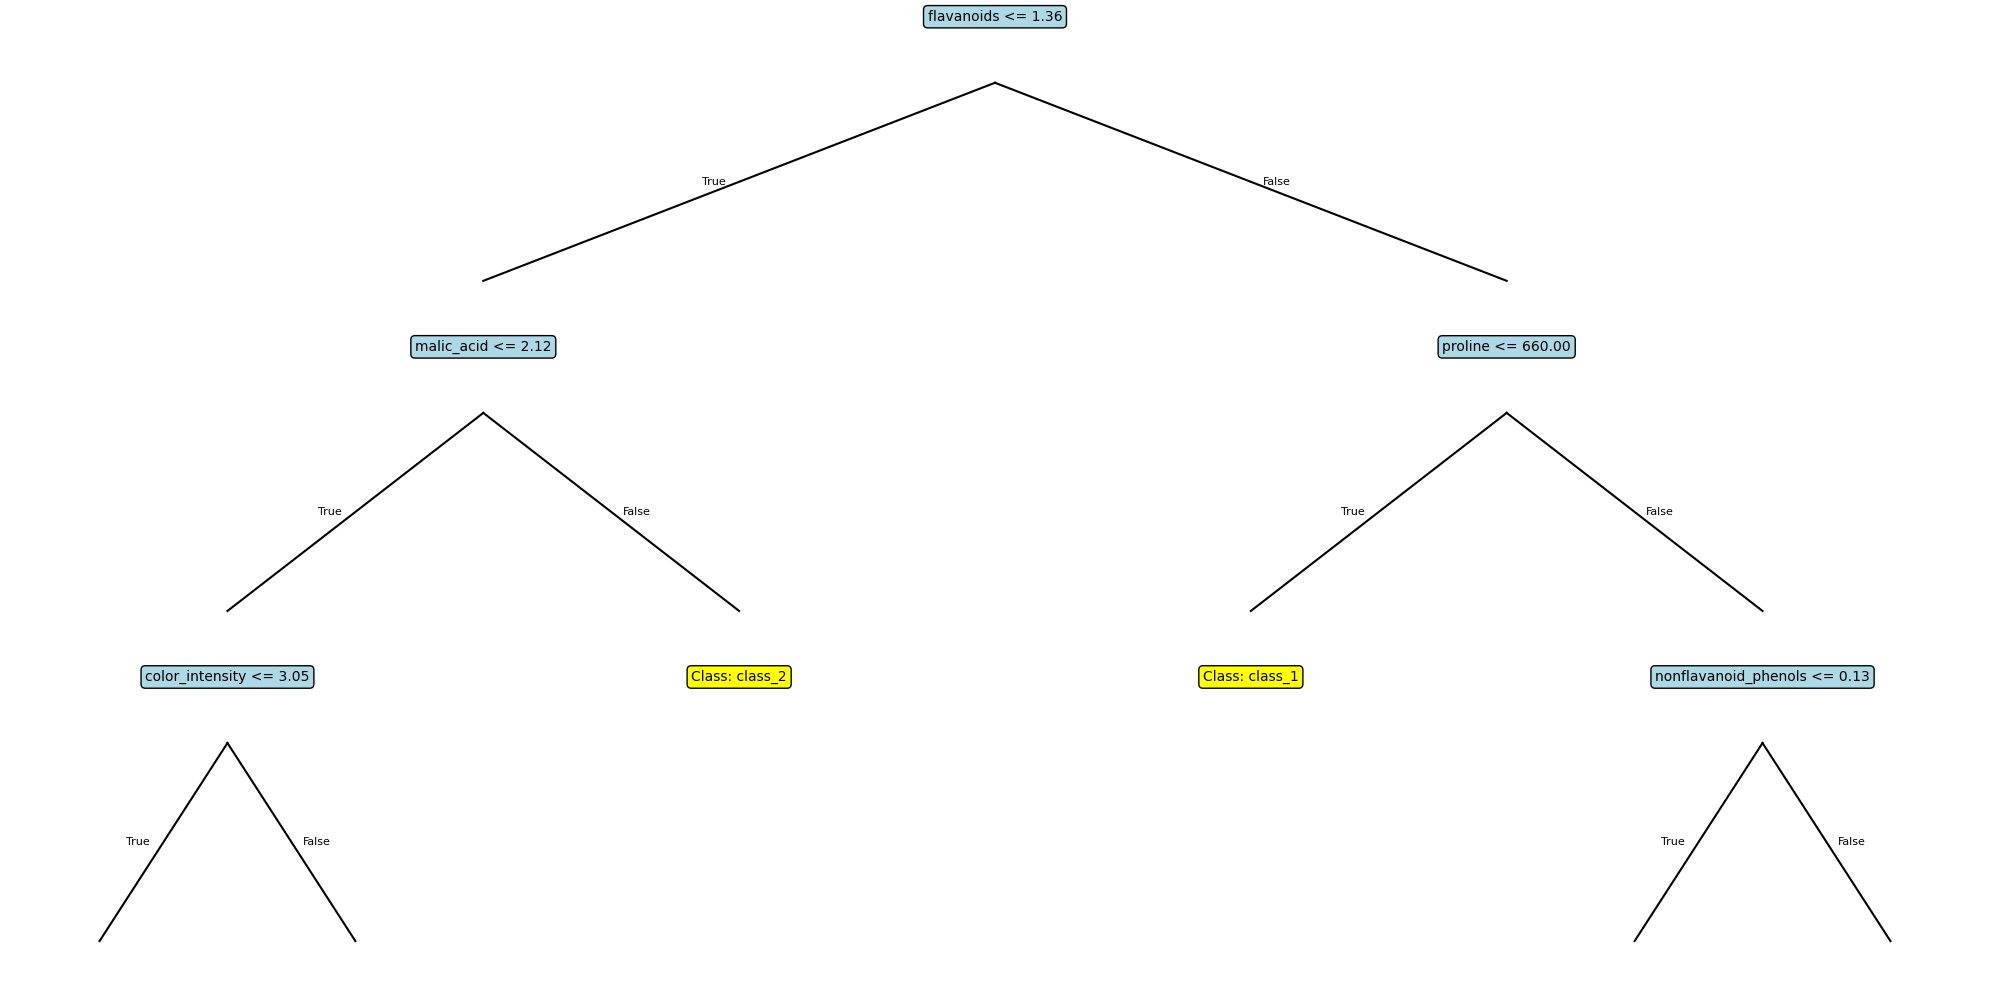

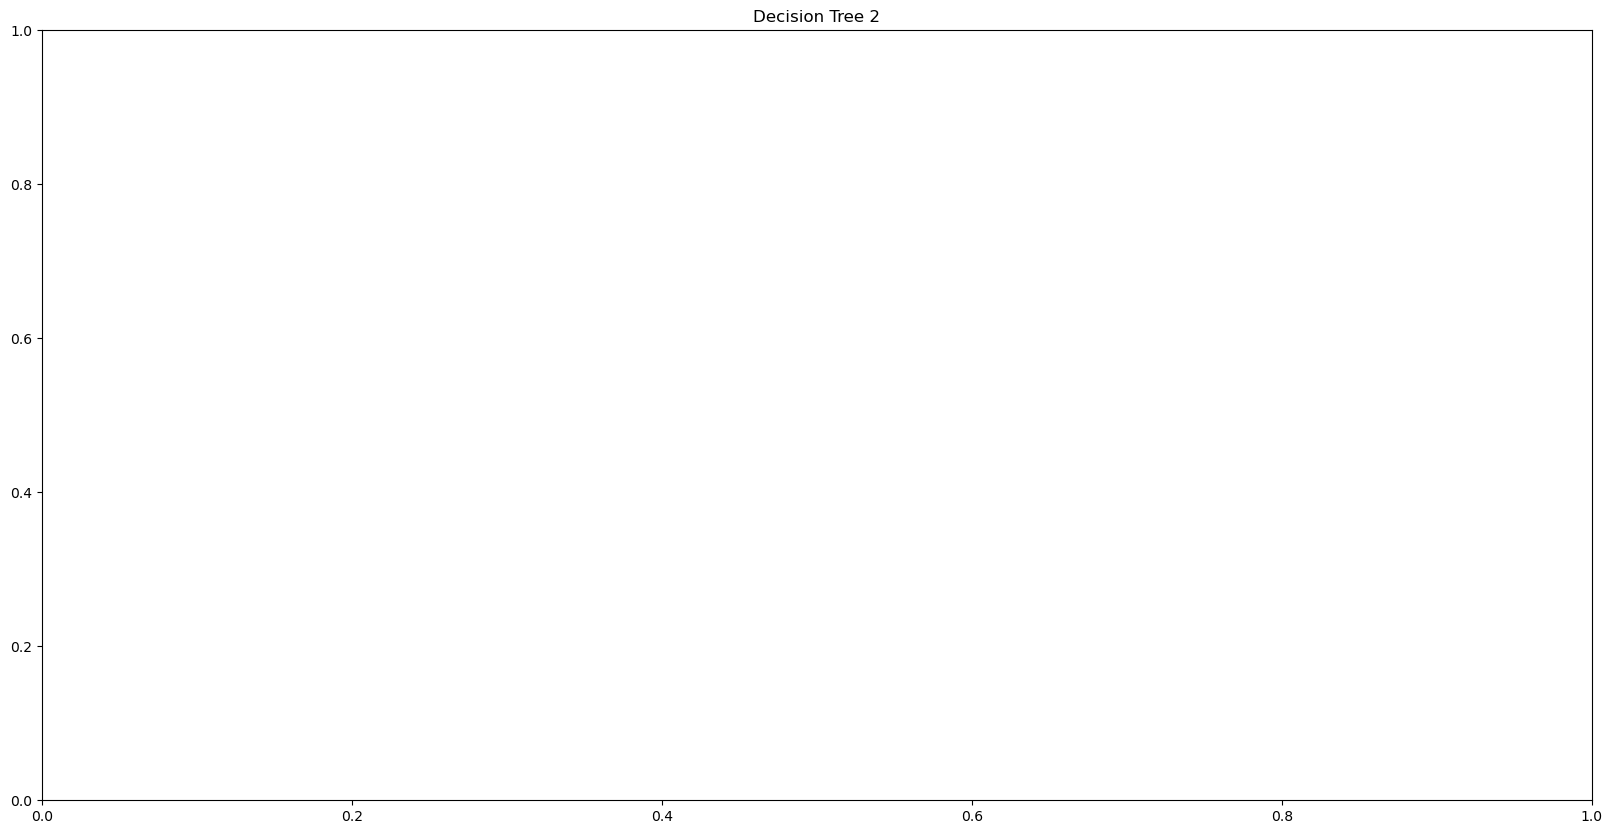

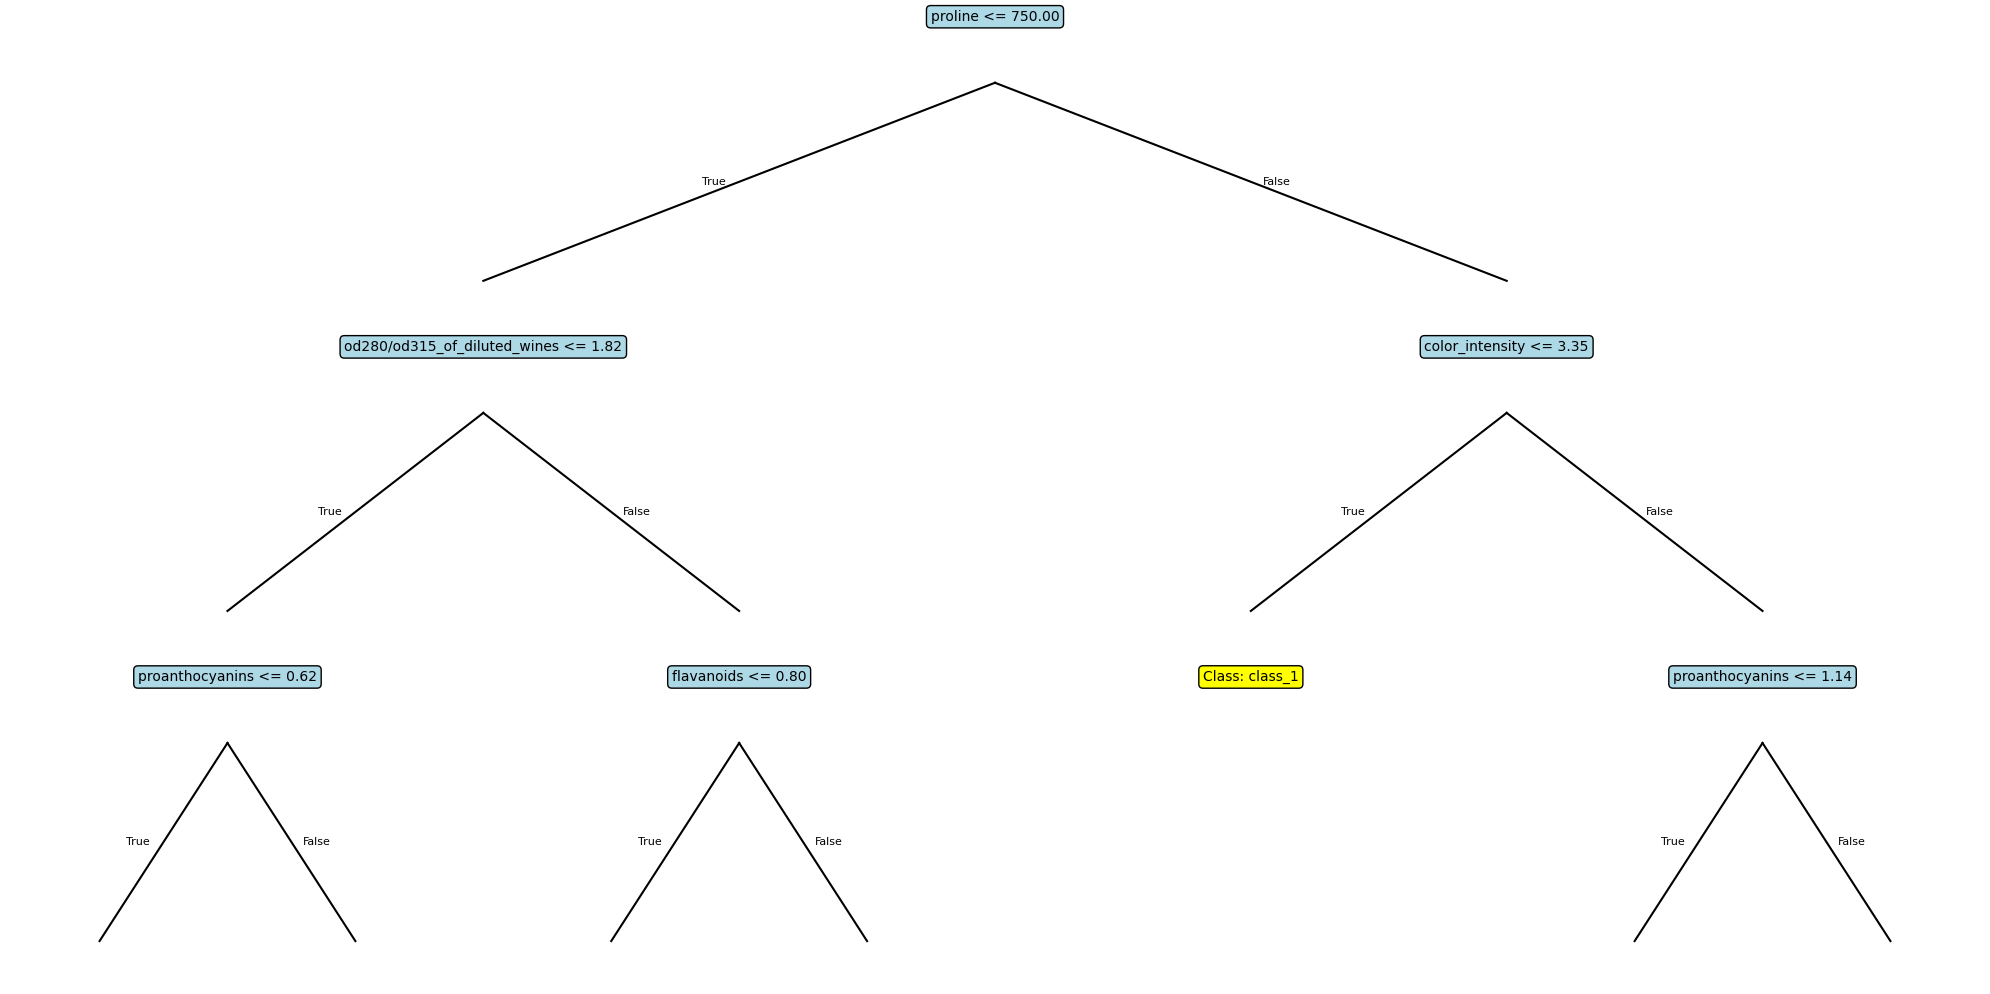

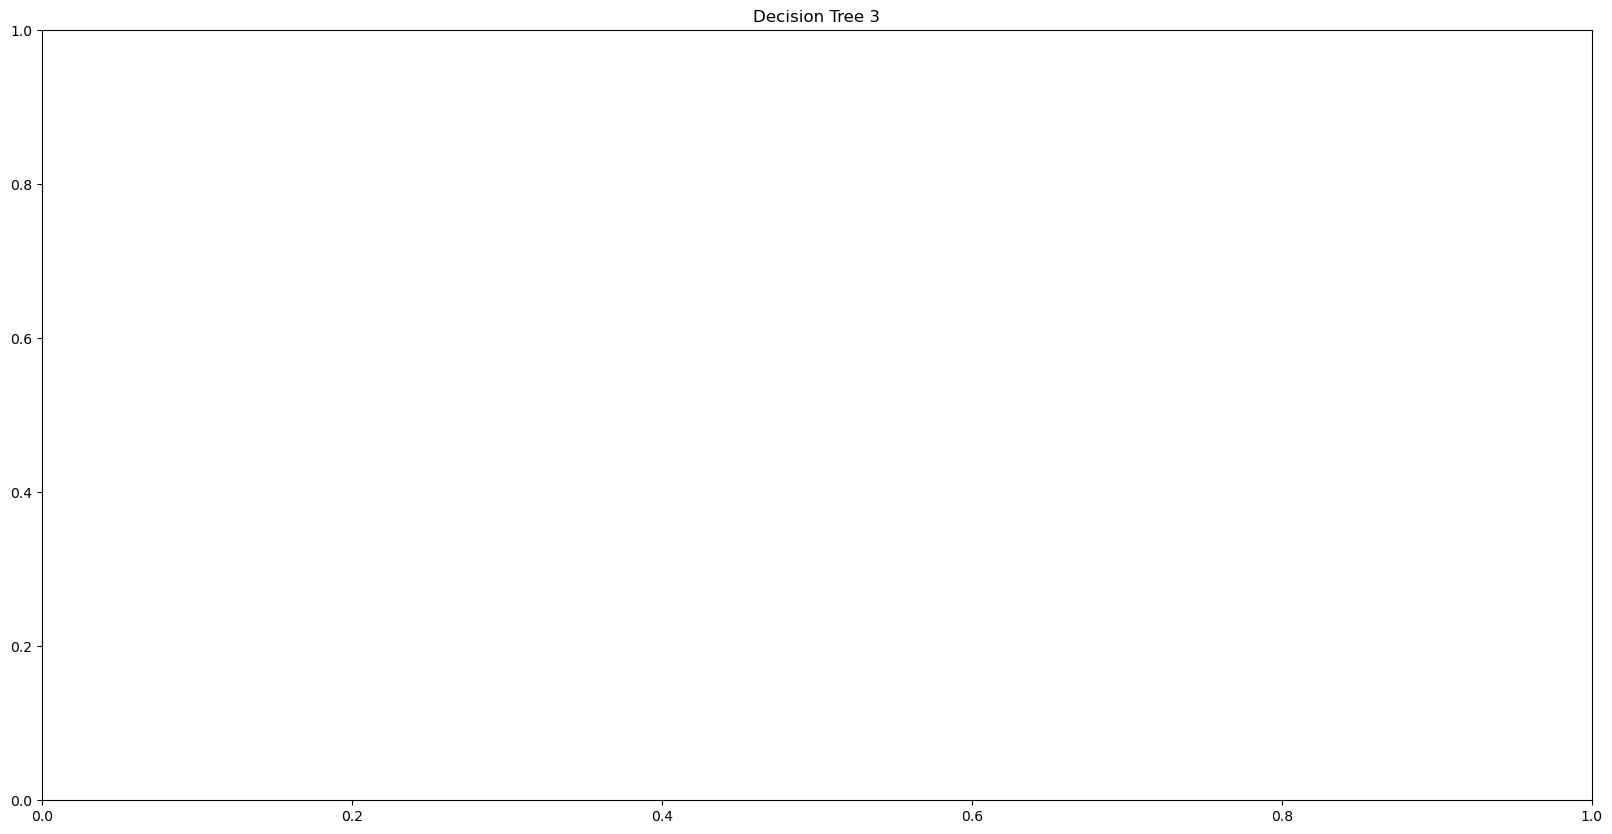

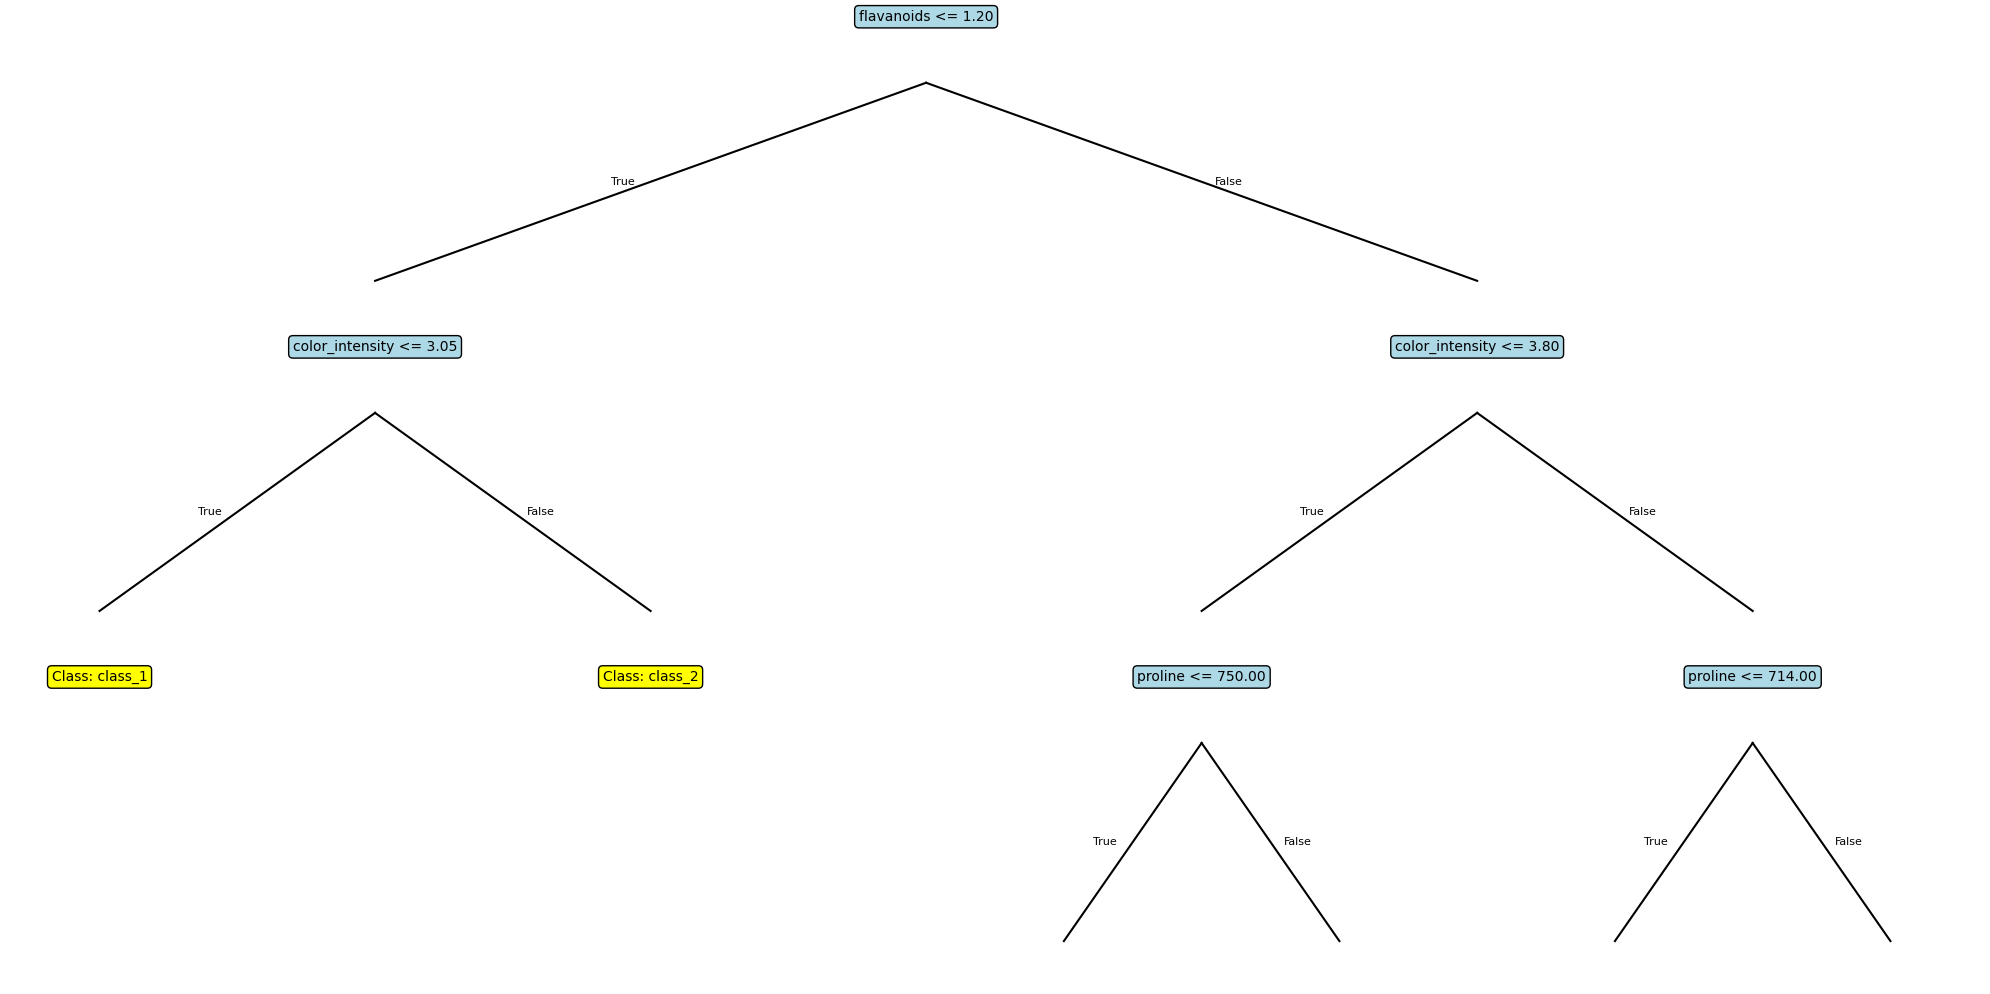

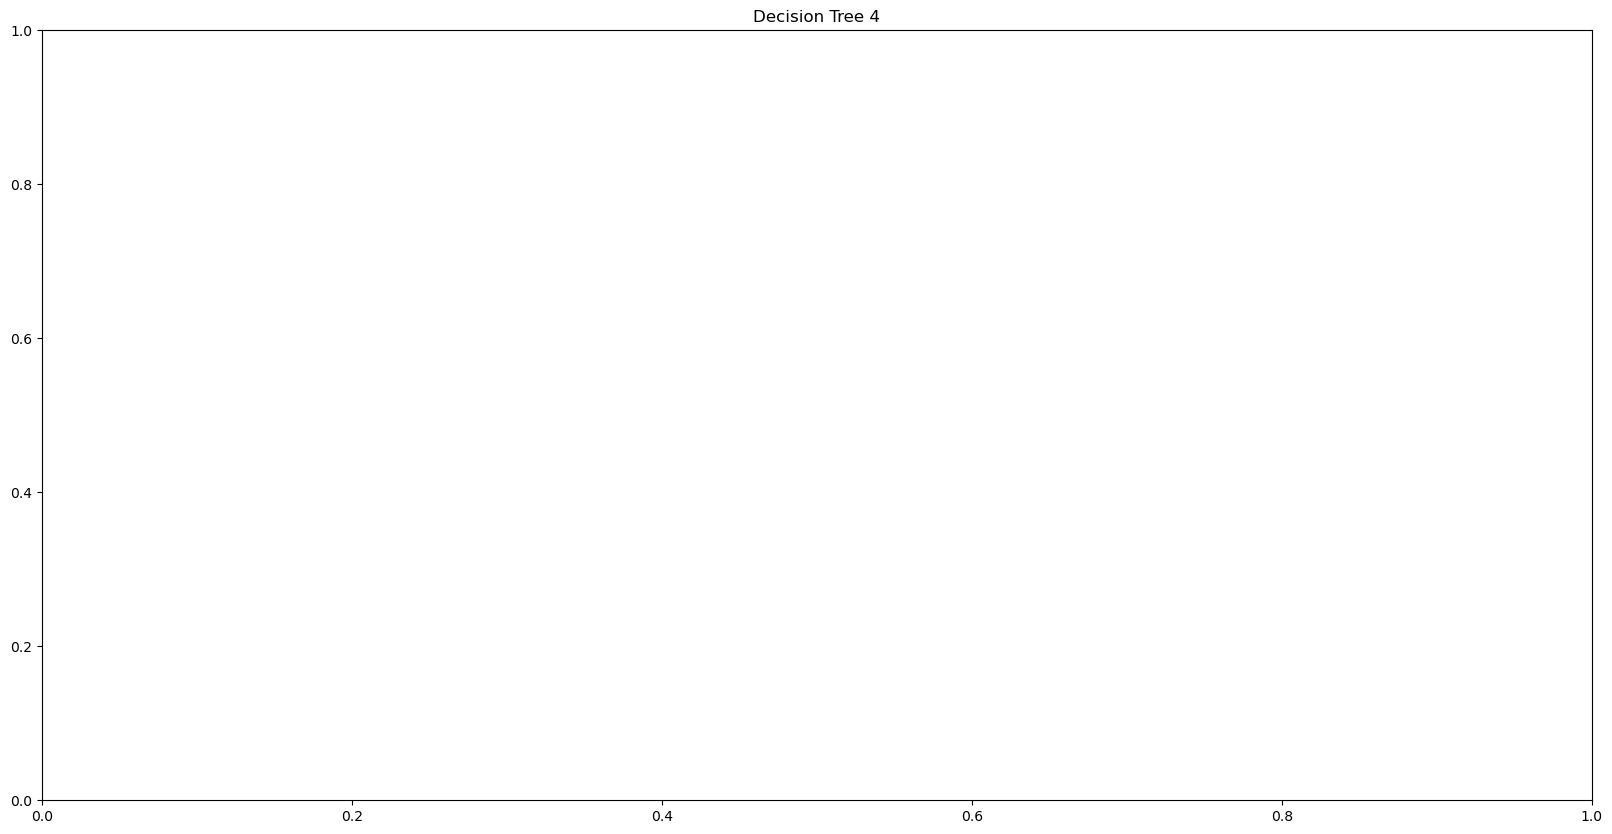

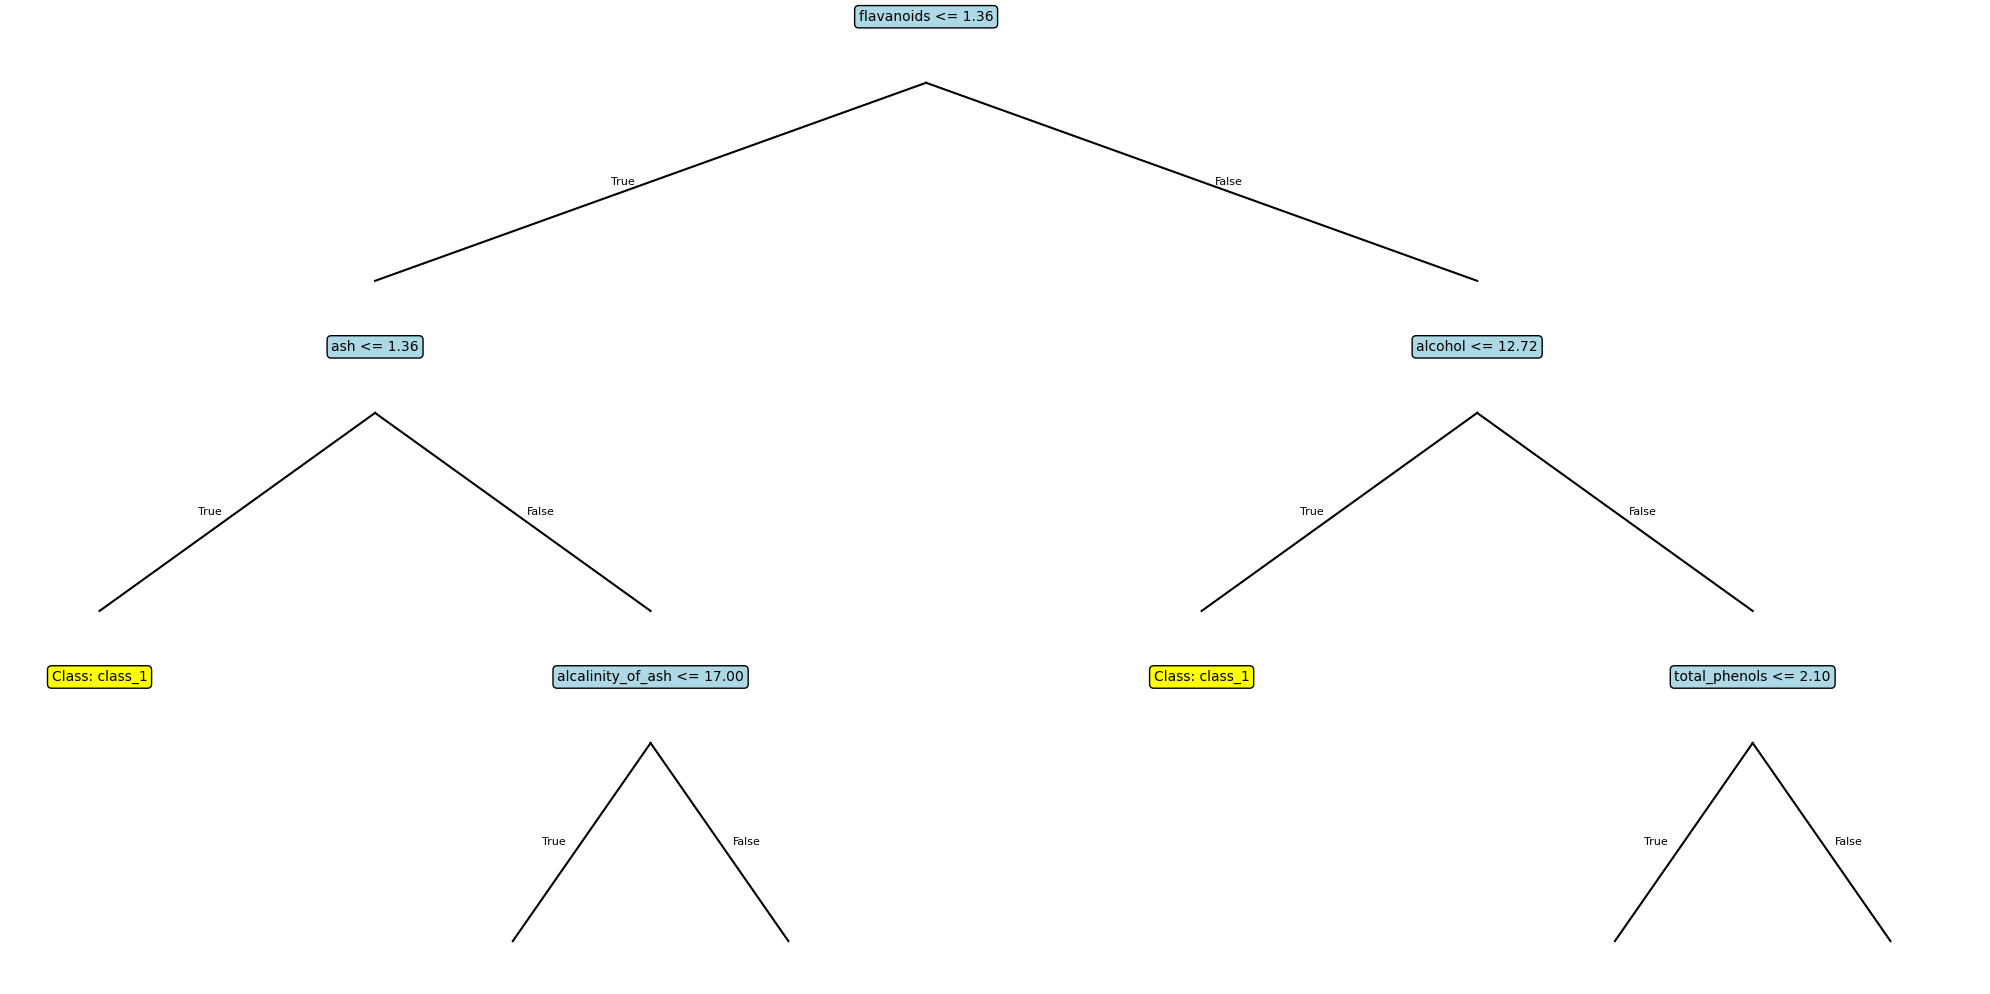

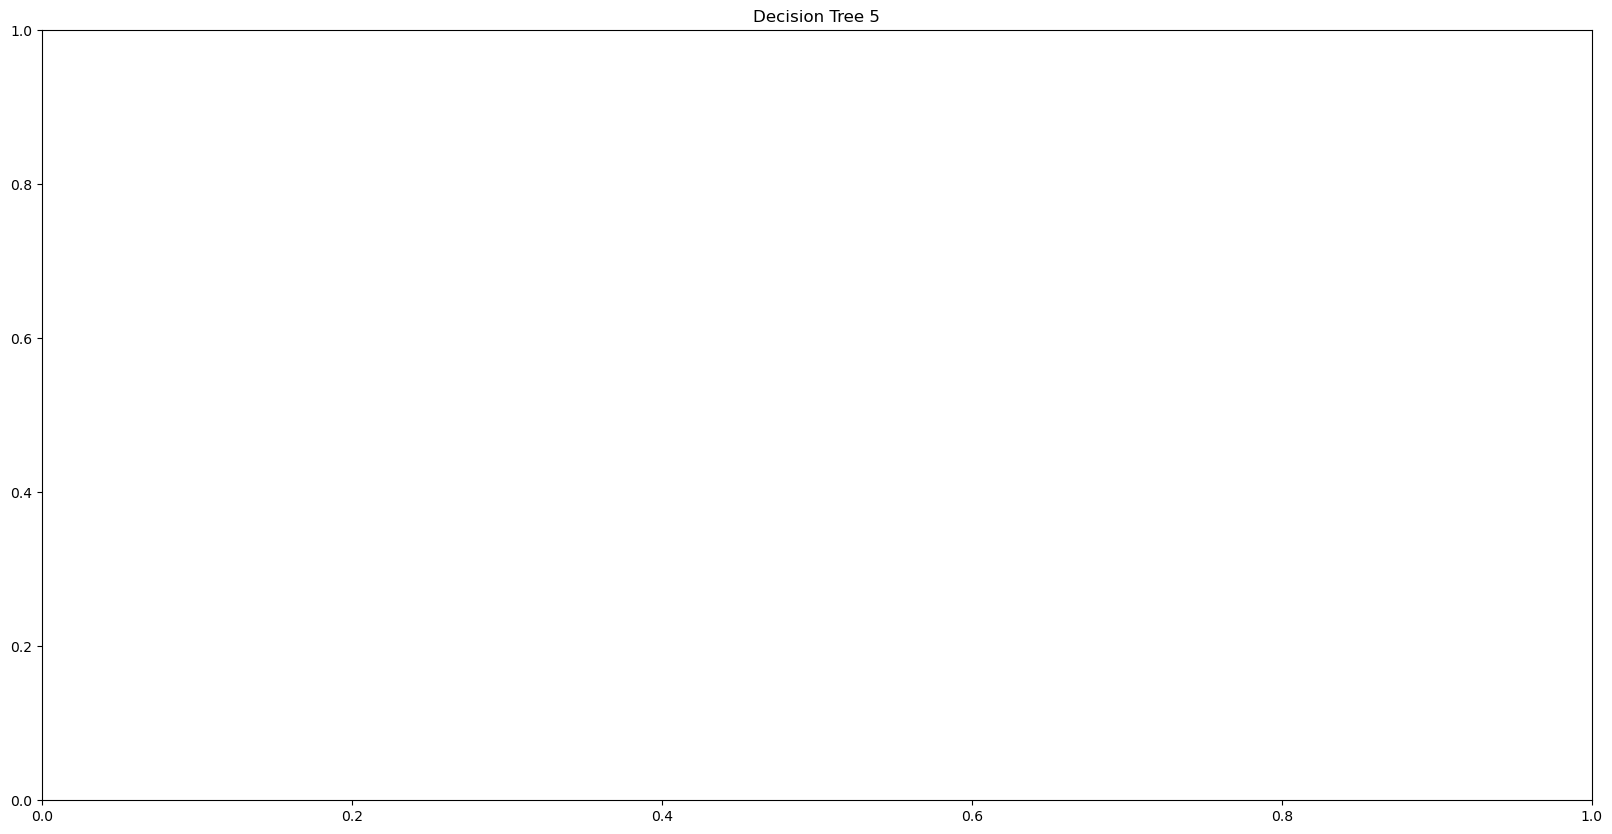

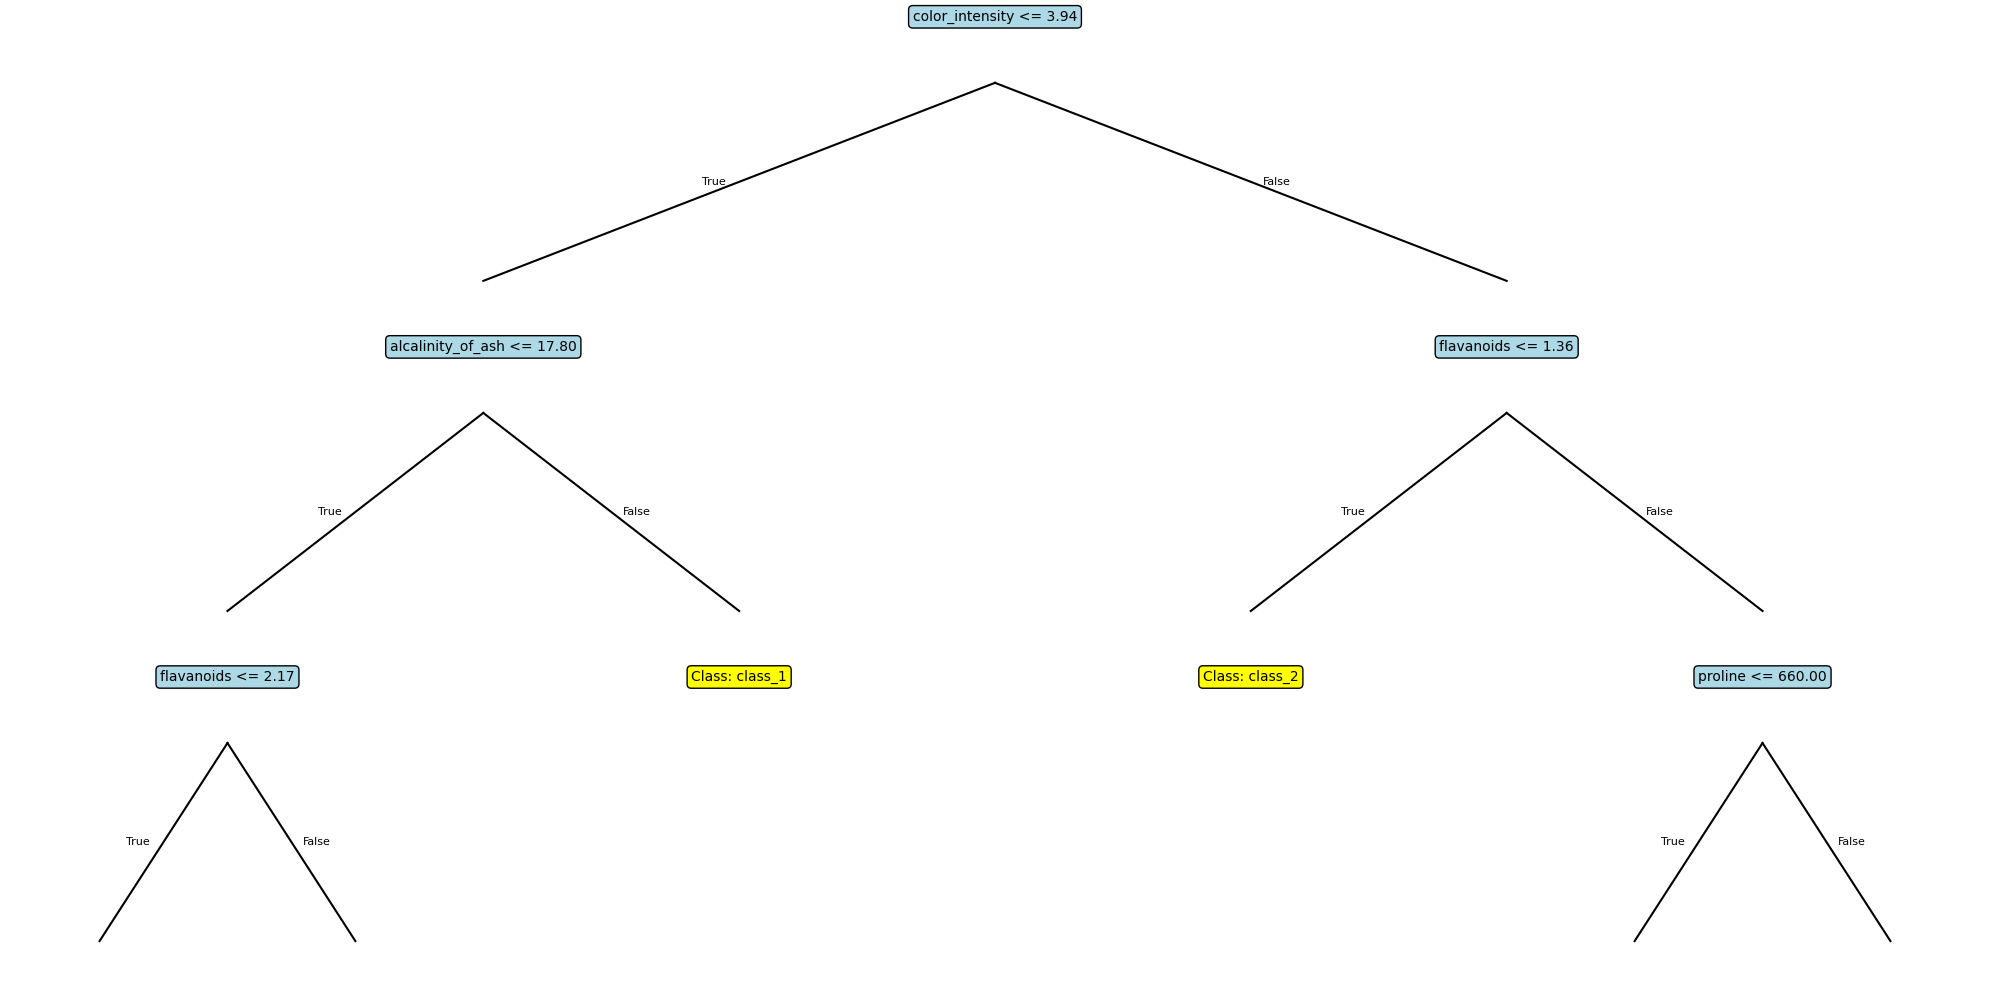

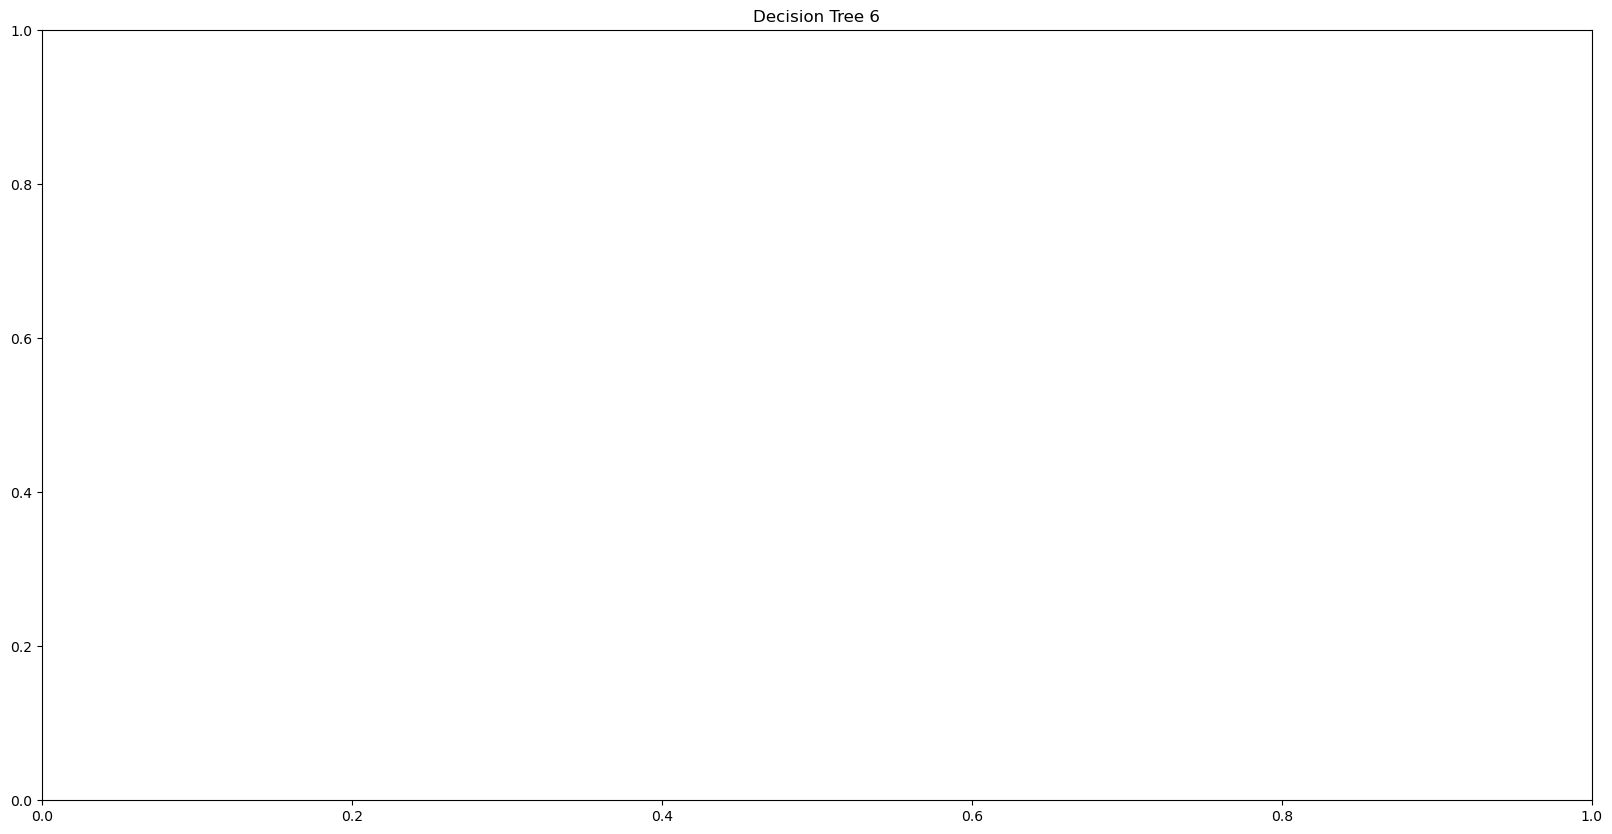

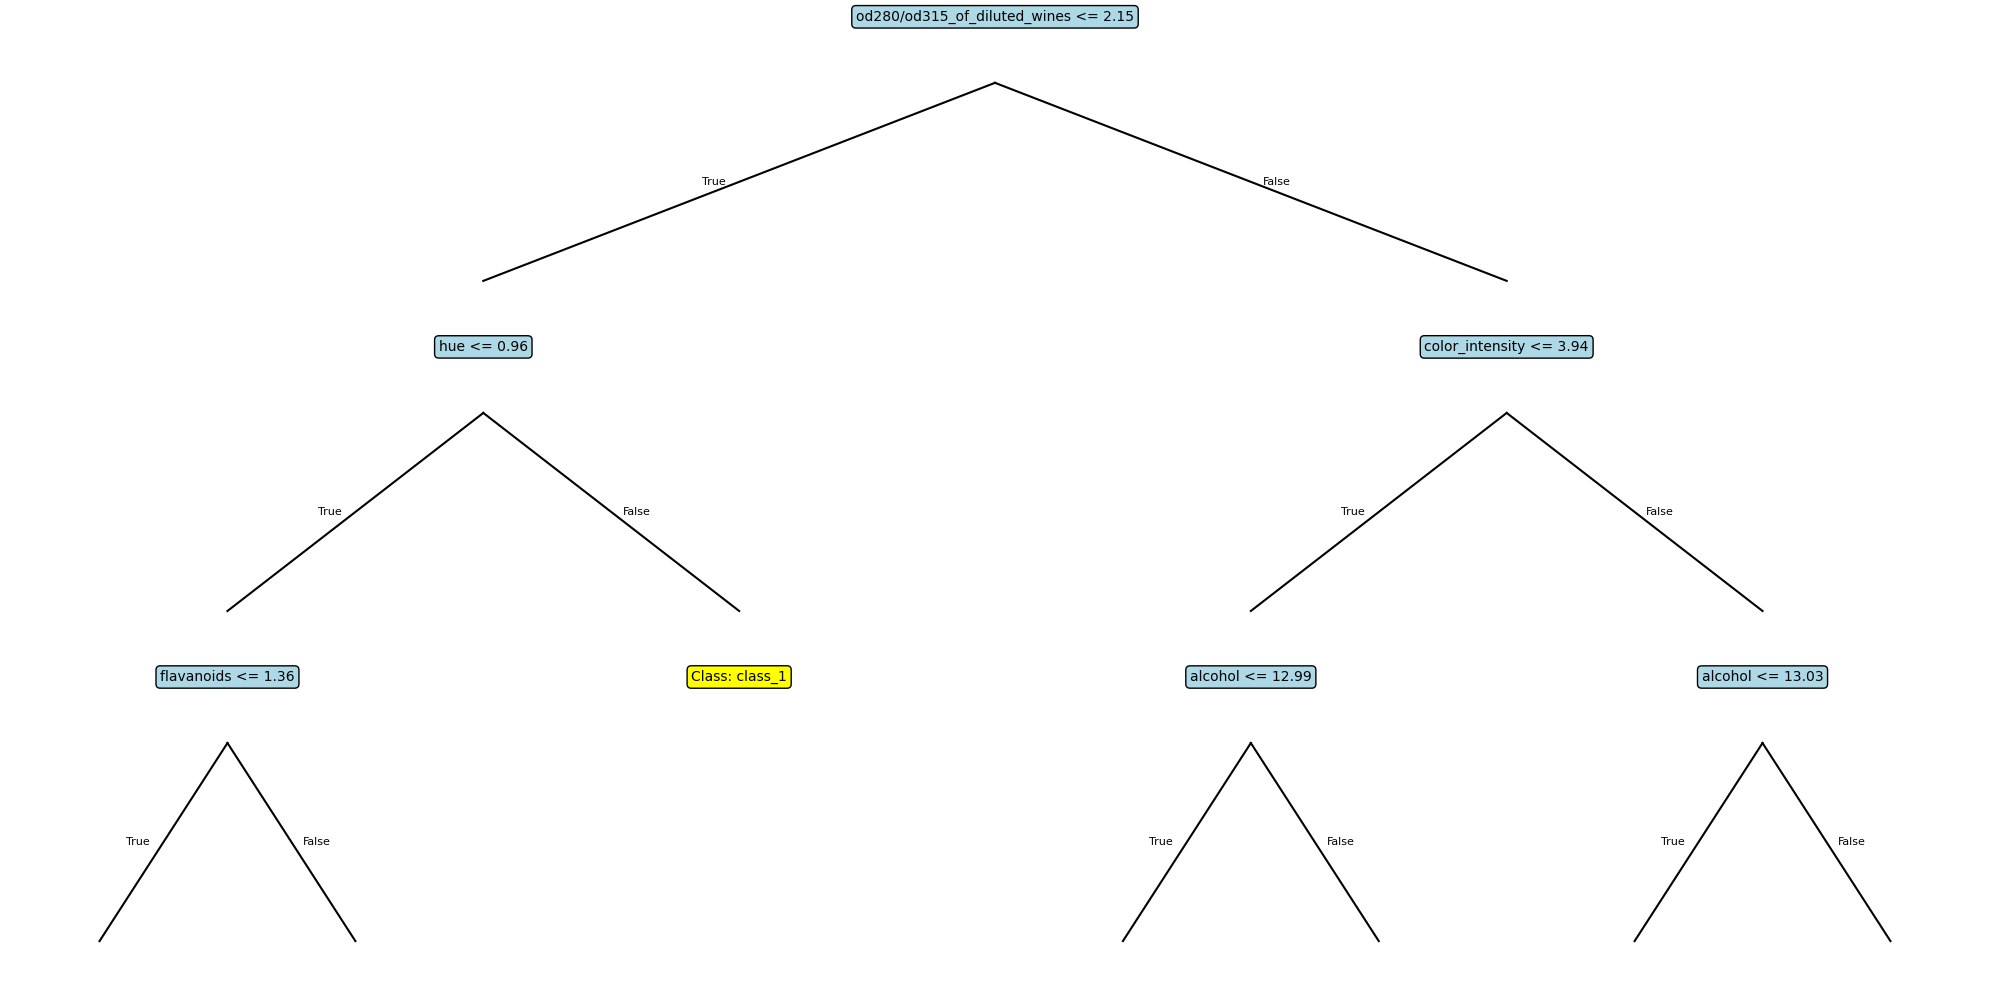

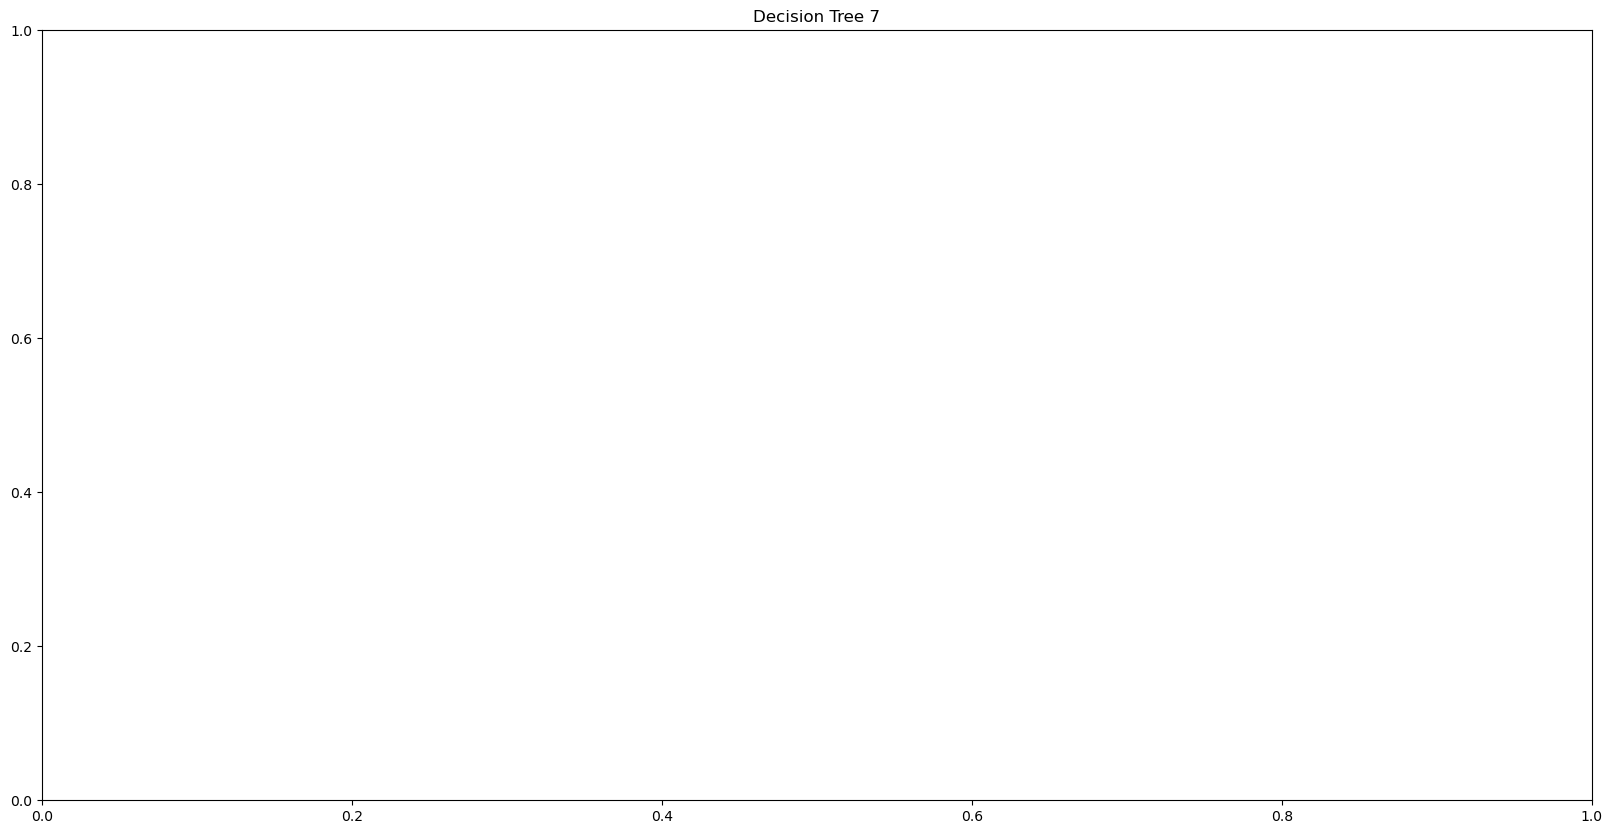

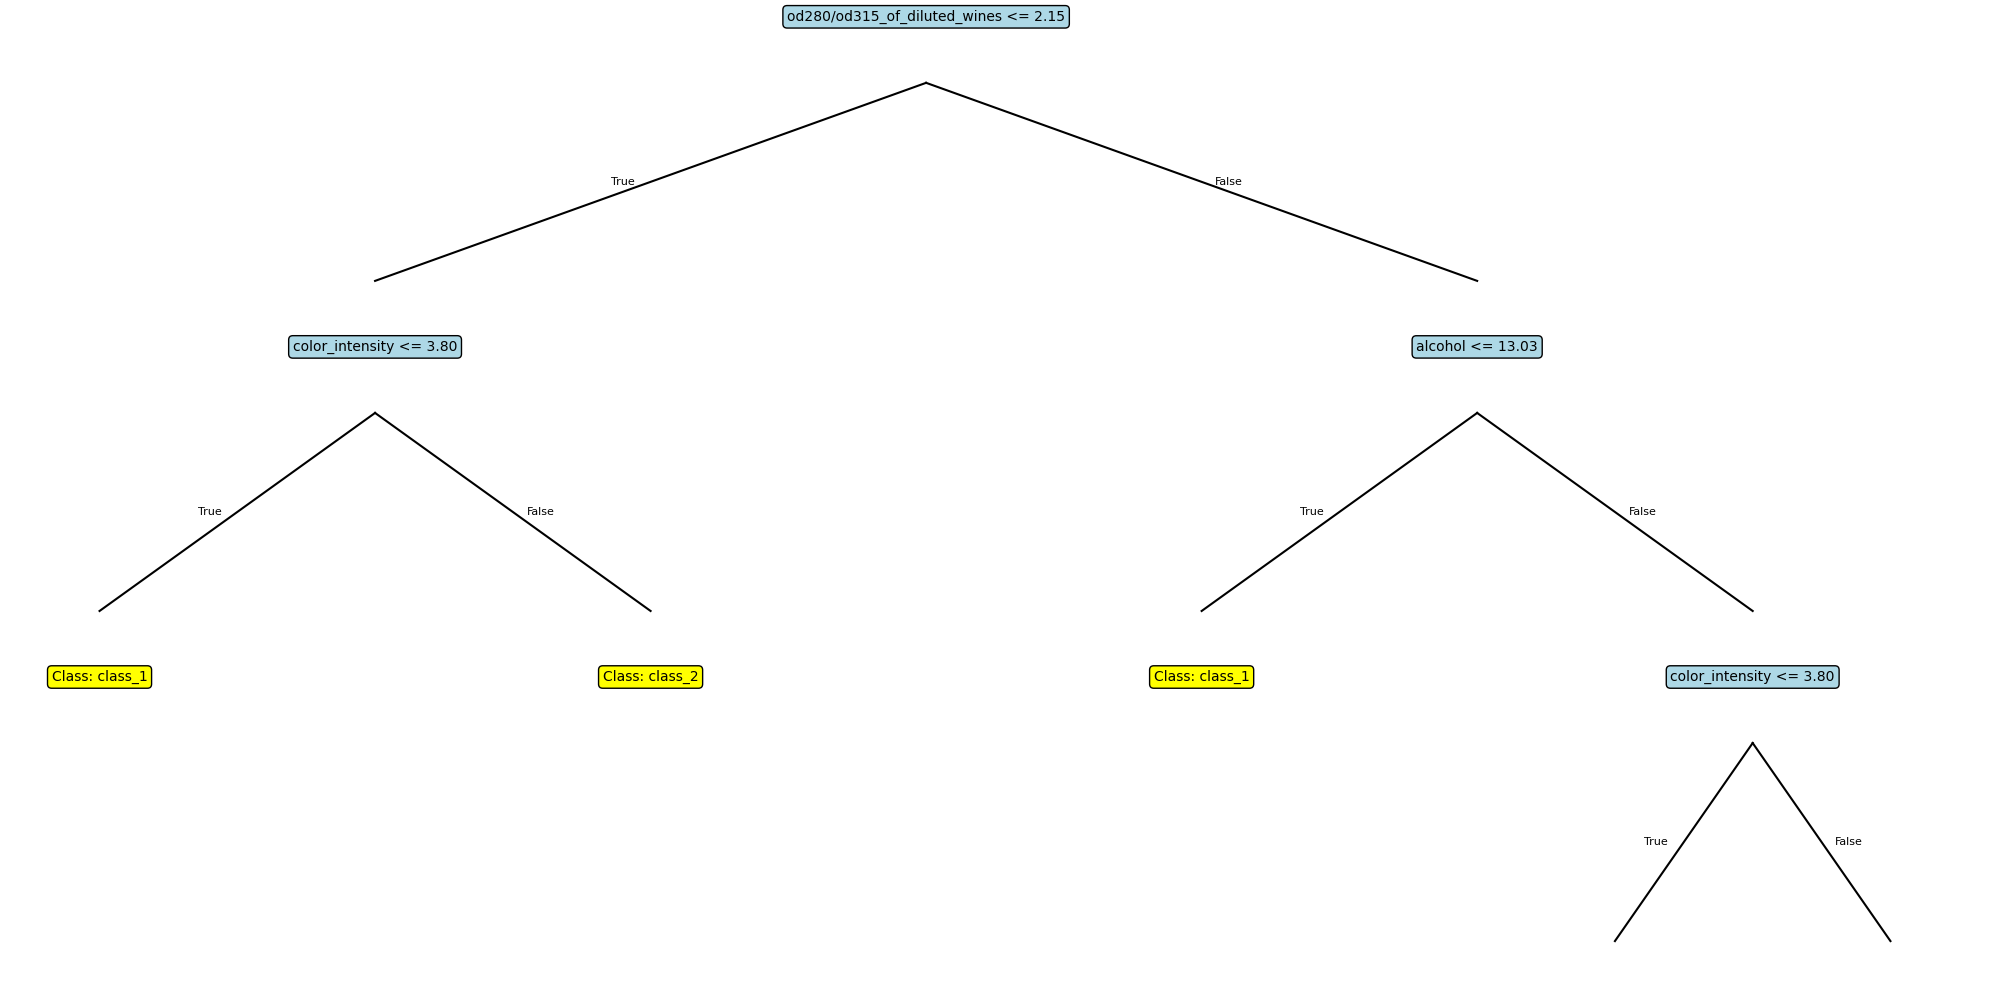

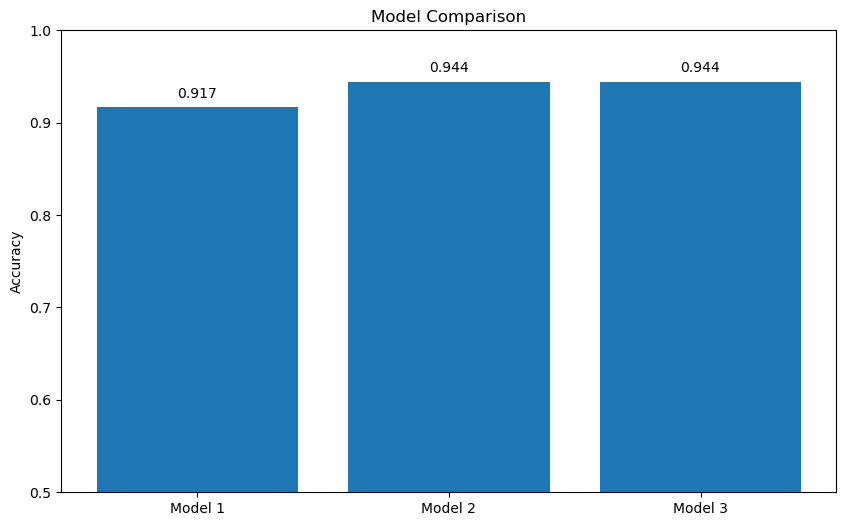

In [120]:
if __name__ == "__main__":
    exercise2()